# GitHub User Churn Predictor
## EDA & Feature Selection Notebook
**Course:** Introduction to Data Science — Informatics Engineering  
**Author:** Ana Barrios  
**Data Source:** GitHub REST API  

---

## Notebook Structure

This notebook is the analytical audit trail for the GitHub User Churn Predictor project.  
It tells the full story from raw data to final model, following the pipeline defined in the course:

| Section | Description |
|---------|-------------|
| 1 | Raw data exploration |
| 2 | Churn label analysis |
| 3 | Feature generation & justification |
| 4 | Feature selection — four methods |
| 5 | Comparison table & final decision |
| 6 | PCA dimensionality reduction  |
| 7 | SVD decomposition |
| 8 | Network graph analysis |
| 9 | Final model performance |

**Key question this notebook answers:**  
*Which behavioral signals from GitHub user profiles actually predict whether a user will stop contributing?*


---
## Setup — Imports & Configuration


In [48]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'app'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})
CHURN_COLORS = {0: '#2196F3', 1: '#F44336'}  # blue=retained, red=churned

print('All imports successful.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')


All imports successful.
pandas 3.0.3 | numpy 2.4.6


---
## Section 1 — Raw Data Exploration

The raw dataset was collected by `scraper.py` (Step 3) using the GitHub REST API.  
It contains public profile information for 300 GitHub users, including timestamps,  
social graph counts, and repository statistics.

**What we are looking at:** raw API fields before any transformation.  
Feature engineering happens in Section 3.


In [49]:
# Load raw data
RAW_PATH = '../data/raw/github_users.csv'
df_raw = pd.read_csv(RAW_PATH)

print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(5)


Shape: 300 rows x 15 columns
Columns: ['username', 'public_repos', 'public_gists', 'followers', 'following', 'created_at', 'updated_at', 'bio', 'blog', 'company', 'email', 'hireable', 'days_since_update', 'days_since_last_push', 'churn']


,username,public_repos,public_gists,followers,following,created_at,updated_at,bio,blog,company,email,hireable,days_since_update,days_since_last_push,churn
0,SergeyKhval,41,1,50,20,2016-01-24T16:49:32Z,2026-04-06T17:47:36Z,NaN,https://openapply.app,NaN,sergeykhval@gmail.com,NaN,64,0.0,0
1,stunn-areeb09,28,0,10,22,2018-02-12T10:33:26Z,2026-03-11T07:04:11Z,An avid learner and a passionate Problem Solve...,NaN,NaN,areeb.wadood9@gmail.com,True,90,567.0,1
2,C-Sinclair,102,10,50,207,2018-10-03T08:40:41Z,2026-05-18T20:38:06Z,🧙 Pushing bits down pipes since '15,https://c.sinclair.software/,@team-alembic,conor@sinclair.software,NaN,21,22.0,0
3,DrKLO,4,0,2889,0,2009-04-01T13:23:24Z,2026-06-01T11:21:49Z,NaN,NaN,NaN,NaN,NaN,8,19.0,0
4,rajkumardusad,6,0,3124,0,2017-10-16T06:53:58Z,2026-05-27T13:30:25Z,Software Engineer | Python | Java | JavaScript...,https://github.com/rajkumardusad,NaN,NaN,NaN,13,492.0,1


In [50]:
# Data types and null counts
print('=== Column Info ===')
df_raw.info()


=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   username              300 non-null    str    
 1   public_repos          300 non-null    int64  
 2   public_gists          300 non-null    int64  
 3   followers             300 non-null    int64  
 4   following             300 non-null    int64  
 5   created_at            300 non-null    str    
 6   updated_at            300 non-null    str    
 7   bio                   164 non-null    str    
 8   blog                  164 non-null    str    
 9   company               127 non-null    str    
 10  email                 108 non-null    str    
 11  hireable              63 non-null     object 
 12  days_since_update     300 non-null    int64  
 13  days_since_last_push  295 non-null    float64
 14  churn                 300 non-null    int64  
dtypes: float64(1),

In [51]:
# Missing value analysis
nulls = df_raw.isnull().sum()
null_pct = (nulls / len(df_raw) * 100).round(1)
null_df = pd.DataFrame({'null_count': nulls, 'null_%': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_%', ascending=False)

if null_df.empty:
    print('No missing values in required numeric columns.')
else:
    print('Columns with missing values:')
    print(null_df)


Columns with missing values:
                      null_count  null_%
hireable                     237    79.0
email                        192    64.0
company                      173    57.7
bio                          136    45.3
blog                         136    45.3
days_since_last_push           5     1.7


In [52]:
# Descriptive statistics for numeric raw fields
numeric_cols = ['public_repos', 'public_gists', 'followers', 'following',
                'days_since_update', 'days_since_last_push']
df_raw[numeric_cols].describe().round(2)


,public_repos,public_gists,followers,following,days_since_update,days_since_last_push
count,300.00,300.00,300.00,300.00,300.00,295.00
mean,41.98,4.94,1745.00,765.02,305.44,511.24
std,71.35,13.29,7343.06,7902.14,625.47,744.65
min,0.00,0.00,10.00,0.00,0.00,-1.00
25%,6.75,0.00,40.00,2.00,14.00,19.00
50%,19.00,0.00,50.00,13.50,52.00,130.00
75%,49.00,2.00,100.00,48.00,247.50,683.50
max,596.00,101.00,113180.00,123212.00,3222.00,4405.00


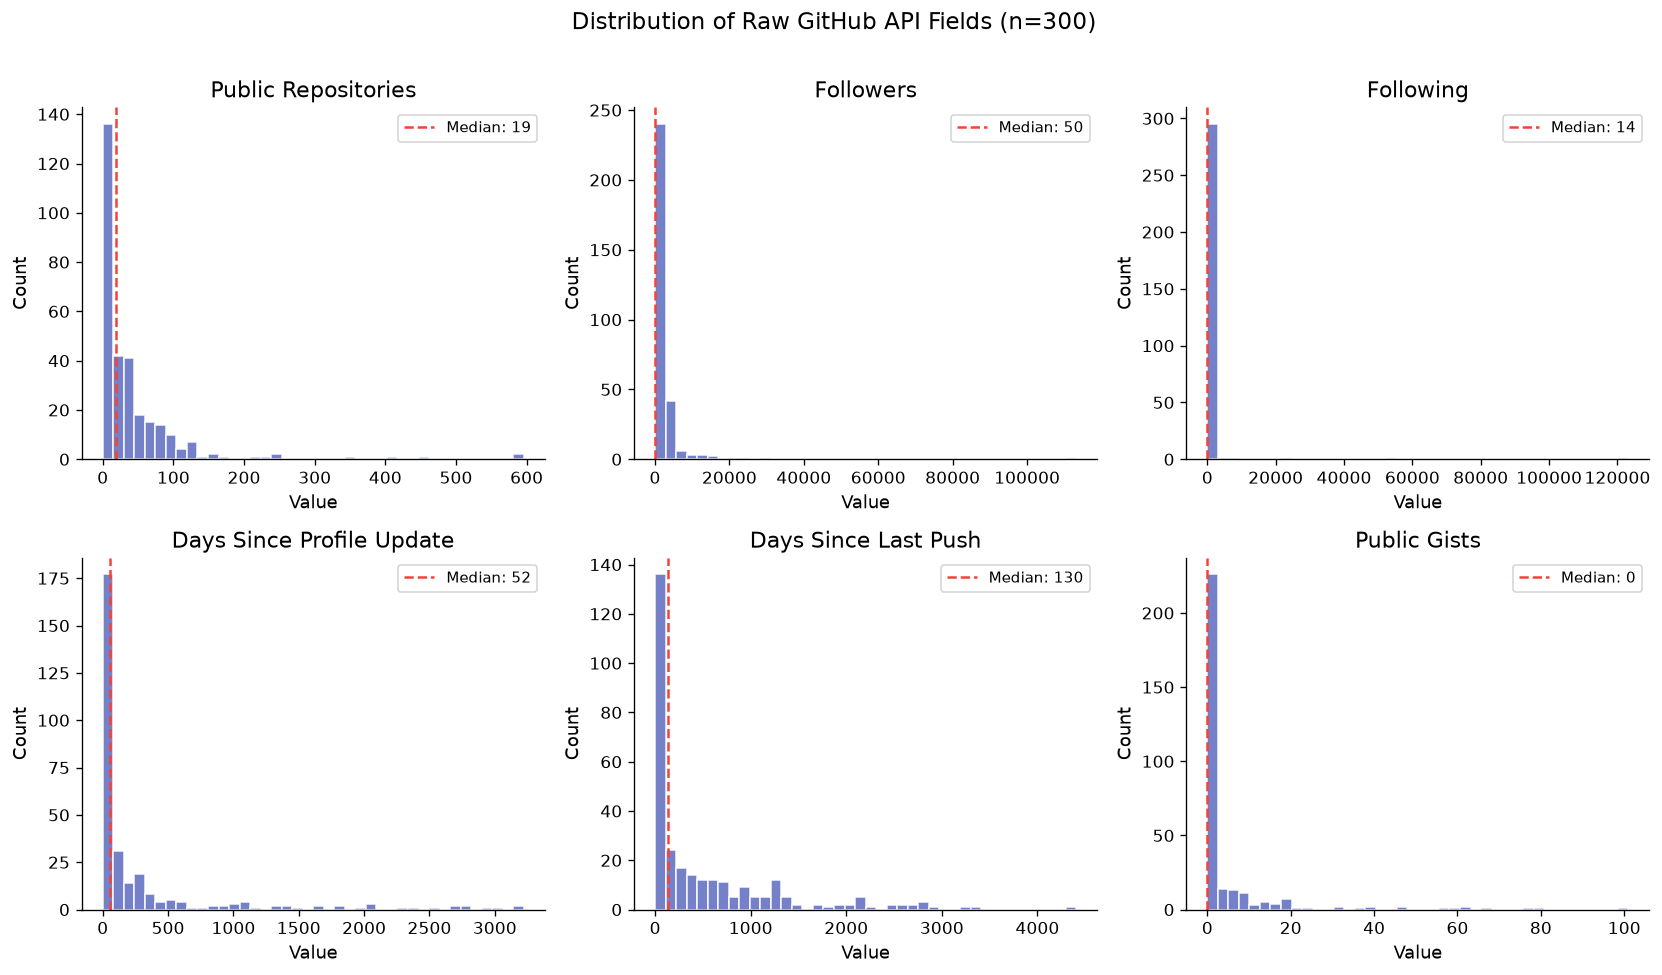

Observation: followers and public_repos are heavily right-skewed.
A small number of accounts dominate the upper range (power-law distribution).
This motivates log-compression in the social_volume feature (Section 3).


In [53]:
# Distribution of key raw fields
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

fields = [
    ('public_repos',          'Public Repositories'),
    ('followers',             'Followers'),
    ('following',             'Following'),
    ('days_since_update',     'Days Since Profile Update'),
    ('days_since_last_push',  'Days Since Last Push'),
    ('public_gists',          'Public Gists'),
]

for ax, (col, label) in zip(axes, fields):
    data = df_raw[col].dropna()
    ax.hist(data, bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    median_val = data.median()
    ax.axvline(median_val, color='#F44336', linestyle='--', linewidth=1.5,
               label=f'Median: {median_val:.0f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Raw GitHub API Fields (n=300)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('raw_distributions.png', bbox_inches='tight')
plt.show()
print('Observation: followers and public_repos are heavily right-skewed.')
print('A small number of accounts dominate the upper range (power-law distribution).')
print('This motivates log-compression in the social_volume feature (Section 3).')


---
## Section 2 — Churn Label Analysis

### Churn Label Definition (Step 3)

The churn label was constructed in `scraper.py` using this rule:

> **A user is labeled churned (1) if they have not pushed code to any public  
> repository in the last 365 days.**

**Why 365 days?**  
- GitHub developers switch jobs, work privately, or take breaks for 3–6 months  
  without truly churning. A 180-day threshold would over-flag these users.  
- 365 days aligns with a full annual development cycle.  
- The fallback chain: `days_since_last_push` (primary) → `days_since_update`  
  (when push data is unavailable) ensures robust labeling across all users.

**Business critique:**  
365 days is conservative for a real retention intervention. By the time a user  
crosses this threshold, they have been gone for a full year — the intervention  
window has almost certainly passed. A 180-day threshold would be more actionable  
for a product team. This is a documented limitation in the project report.


In [54]:
# Churn distribution
churn_counts = df_raw['churn'].value_counts()
churn_pct    = df_raw['churn'].value_counts(normalize=True) * 100

print('=== Churn Label Distribution ===')
print(f"Retained (0): {churn_counts[0]:>4}  ({churn_pct[0]:.1f}%)")
print(f"Churned  (1): {churn_counts[1]:>4}  ({churn_pct[1]:.1f}%)")
print(f"Churn rate: {churn_pct[1]:.1f}% (minimum required: 10%) -> PASS")


=== Churn Label Distribution ===
Retained (0):  180  (60.0%)
Churned  (1):  120  (40.0%)
Churn rate: 40.0% (minimum required: 10%) -> PASS


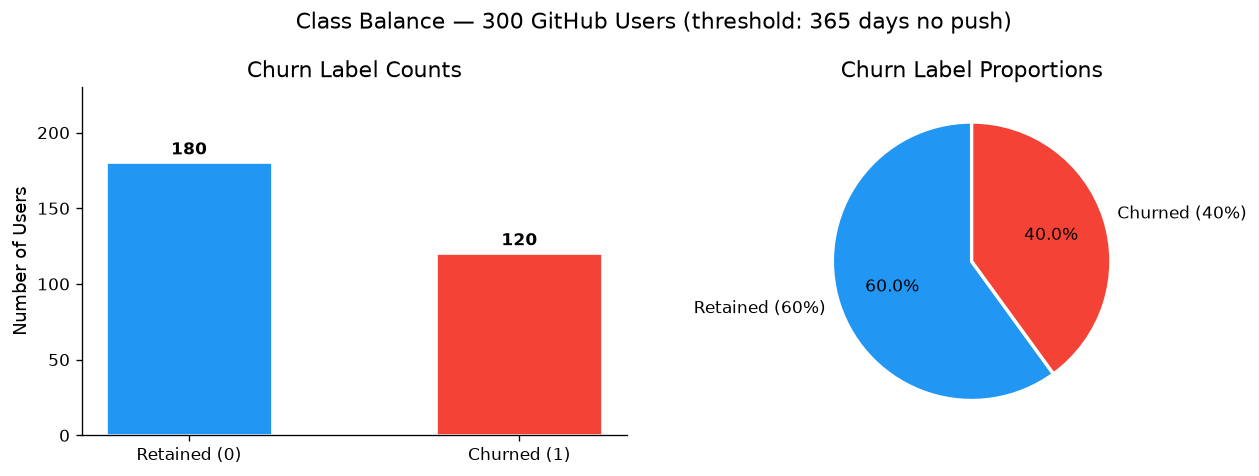

Class balance: 60% retained / 40% churned.
The 40% churn rate is well above the 10% minimum. No resampling needed.


In [55]:
# Visualize churn balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = ax1.bar(['Retained (0)', 'Churned (1)'],
               [churn_counts[0], churn_counts[1]],
               color=['#2196F3', '#F44336'], width=0.5, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
ax1.set_title('Churn Label Counts')
ax1.set_ylabel('Number of Users')
ax1.set_ylim(0, 230)

# Pie chart
ax2.pie([churn_counts[0], churn_counts[1]],
        labels=['Retained (60%)', 'Churned (40%)'],
        colors=['#2196F3', '#F44336'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Churn Label Proportions')

plt.suptitle('Class Balance — 300 GitHub Users (threshold: 365 days no push)',
             fontsize=13)
plt.tight_layout()
plt.savefig('churn_balance.png', bbox_inches='tight')
plt.show()
print('Class balance: 60% retained / 40% churned.')
print('The 40% churn rate is well above the 10% minimum. No resampling needed.')


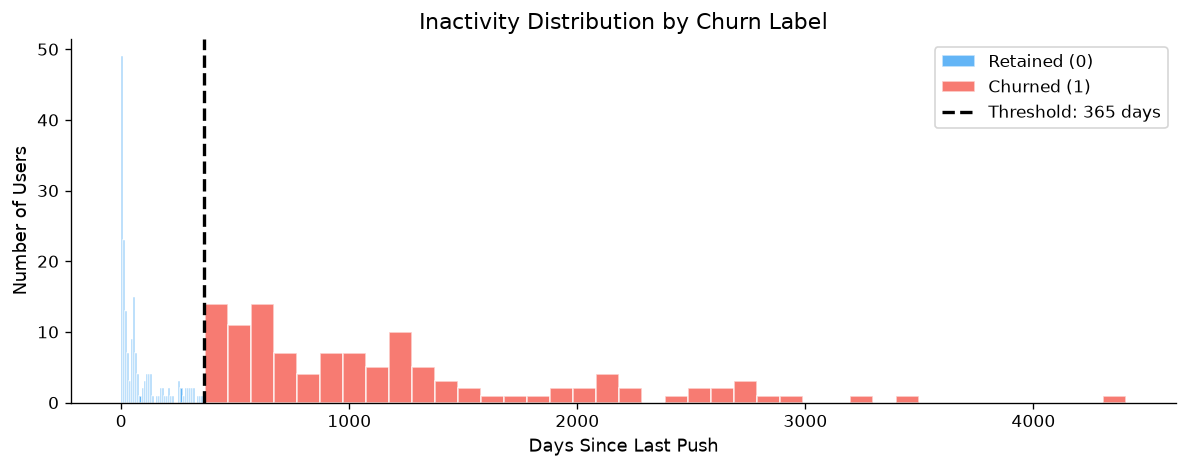

The 365-day threshold clearly separates the two groups.
The overlap zone (300-400 days) represents borderline users the model must learn from.


In [56]:
# Inactivity distribution by churn label
fig, ax = plt.subplots(figsize=(10, 4))

retained = df_raw[df_raw['churn'] == 0]['days_since_last_push'].dropna()
churned  = df_raw[df_raw['churn'] == 1]['days_since_last_push'].dropna()

ax.hist(retained, bins=40, alpha=0.7, color='#2196F3', label='Retained (0)',
        edgecolor='white')
ax.hist(churned,  bins=40, alpha=0.7, color='#F44336', label='Churned (1)',
        edgecolor='white')
ax.axvline(365, color='black', linestyle='--', linewidth=2, label='Threshold: 365 days')
ax.set_xlabel('Days Since Last Push')
ax.set_ylabel('Number of Users')
ax.set_title('Inactivity Distribution by Churn Label')
ax.legend()
plt.tight_layout()
plt.savefig('inactivity_by_churn.png', bbox_inches='tight')
plt.show()
print('The 365-day threshold clearly separates the two groups.')
print('The overlap zone (300-400 days) represents borderline users the model must learn from.')


---
## Section 3 — Feature Generation (Step 4)

### Core Principle
Raw API fields are not features. A timestamp string is meaningless to any ML algorithm.  
But the **number of days elapsed** since that timestamp is a rich numerical signal.

> Every transformation below is a **hypothesis**: "I believe this derived number  
> captures something meaningful about whether a user will disengage from GitHub."

### The 10 Generated Features

| # | Feature | Type | Hypothesis |
|---|---------|------|------------|
| F1 | `follower_ratio` | Ratio | Social influence quality — passive consumers churn more |
| F2 | `engagement_ratio` | Ratio | Social volume normalized by code output |
| F3 | `days_since_last_activity` | Time (recency) | Primary churn signal — how long since last seen |
| F4 | `account_age_days` | Time (tenure) | Old accounts have proven stickiness |
| F5 | `activity_frequency` | Time (frequency) | Cadence of repo creation — habit loop strength |
| F6 | `repos_per_year` | Aggregation | Rate-normalized productivity, fair across all users |
| F7 | `social_volume` | Aggregation | Log-compressed total social footprint |
| F8 | `profile_completeness` | Aggregation | Investment in platform presence |
| F9 | `has_no_repos` | Binary | Never-activated flag — 0 repos is categorically different |
| F10 | `has_complete_profile` | Binary | Hard threshold on full profile completion |


In [57]:
# Load the processed feature matrix (produced by features.py)
FEATURES_PATH = '../data/processed/github_features.csv'
df_features = pd.read_csv(FEATURES_PATH)

FEATURE_COLUMNS = [
    'follower_ratio', 'engagement_ratio', 'days_since_last_activity',
    'account_age_days', 'activity_frequency', 'repos_per_year',
    'social_volume', 'profile_completeness', 'has_no_repos', 'has_complete_profile'
]

X = df_features[FEATURE_COLUMNS]
y = df_features['churn'].astype(int)

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Churn rate: {y.mean():.1%}')
X.describe().round(3)


Feature matrix: 300 rows x 10 features
Churn rate: 40.0%


,follower_ratio,engagement_ratio,days_since_last_activity,account_age_days,activity_frequency,repos_per_year,social_volume,profile_completeness,has_no_repos,has_complete_profile
count,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000
mean,862.279,454.972,306.563,3712.483,5.224,5.224,5.279,1.727,0.017,0.070
std,3422.484,1975.603,625.460,1220.857,16.241,16.241,2.077,1.204,0.128,0.256
min,0.045,0.123,1.000,311.000,0.000,0.000,2.398,0.000,0.000,0.000
25%,0.806,1.374,15.000,3024.000,0.630,0.630,3.951,1.000,0.000,0.000
50%,2.381,3.595,53.000,3351.000,2.151,2.151,4.727,2.000,0.000,0.000
75%,50.000,25.969,248.500,4706.750,5.027,5.027,5.898,3.000,0.000,0.000
max,28782.000,25760.800,3223.000,6729.000,259.551,259.551,11.766,4.000,1.000,1.000


In [58]:
# Feature means by churn label — the most direct signal check
# If churned (1) and retained (0) have very different means for a feature,
# that feature is likely to be predictive.
means_by_churn = df_features.groupby('churn')[FEATURE_COLUMNS].mean().round(3)
print('=== Feature Means by Churn Label ===')
print('(Large differences between row 0 and row 1 indicate predictive features)')
print()
print(means_by_churn.T.to_string())


=== Feature Means by Churn Label ===
(Large differences between row 0 and row 1 indicate predictive features)

churn                            0         1
follower_ratio             696.467  1110.998
engagement_ratio           351.368   610.377
days_since_last_activity    88.856   633.125
account_age_days          3758.194  3643.917
activity_frequency           7.145     2.343
repos_per_year               7.145     2.343
social_volume                5.440     5.037
profile_completeness         1.906     1.458
has_no_repos                 0.000     0.042
has_complete_profile         0.078     0.058


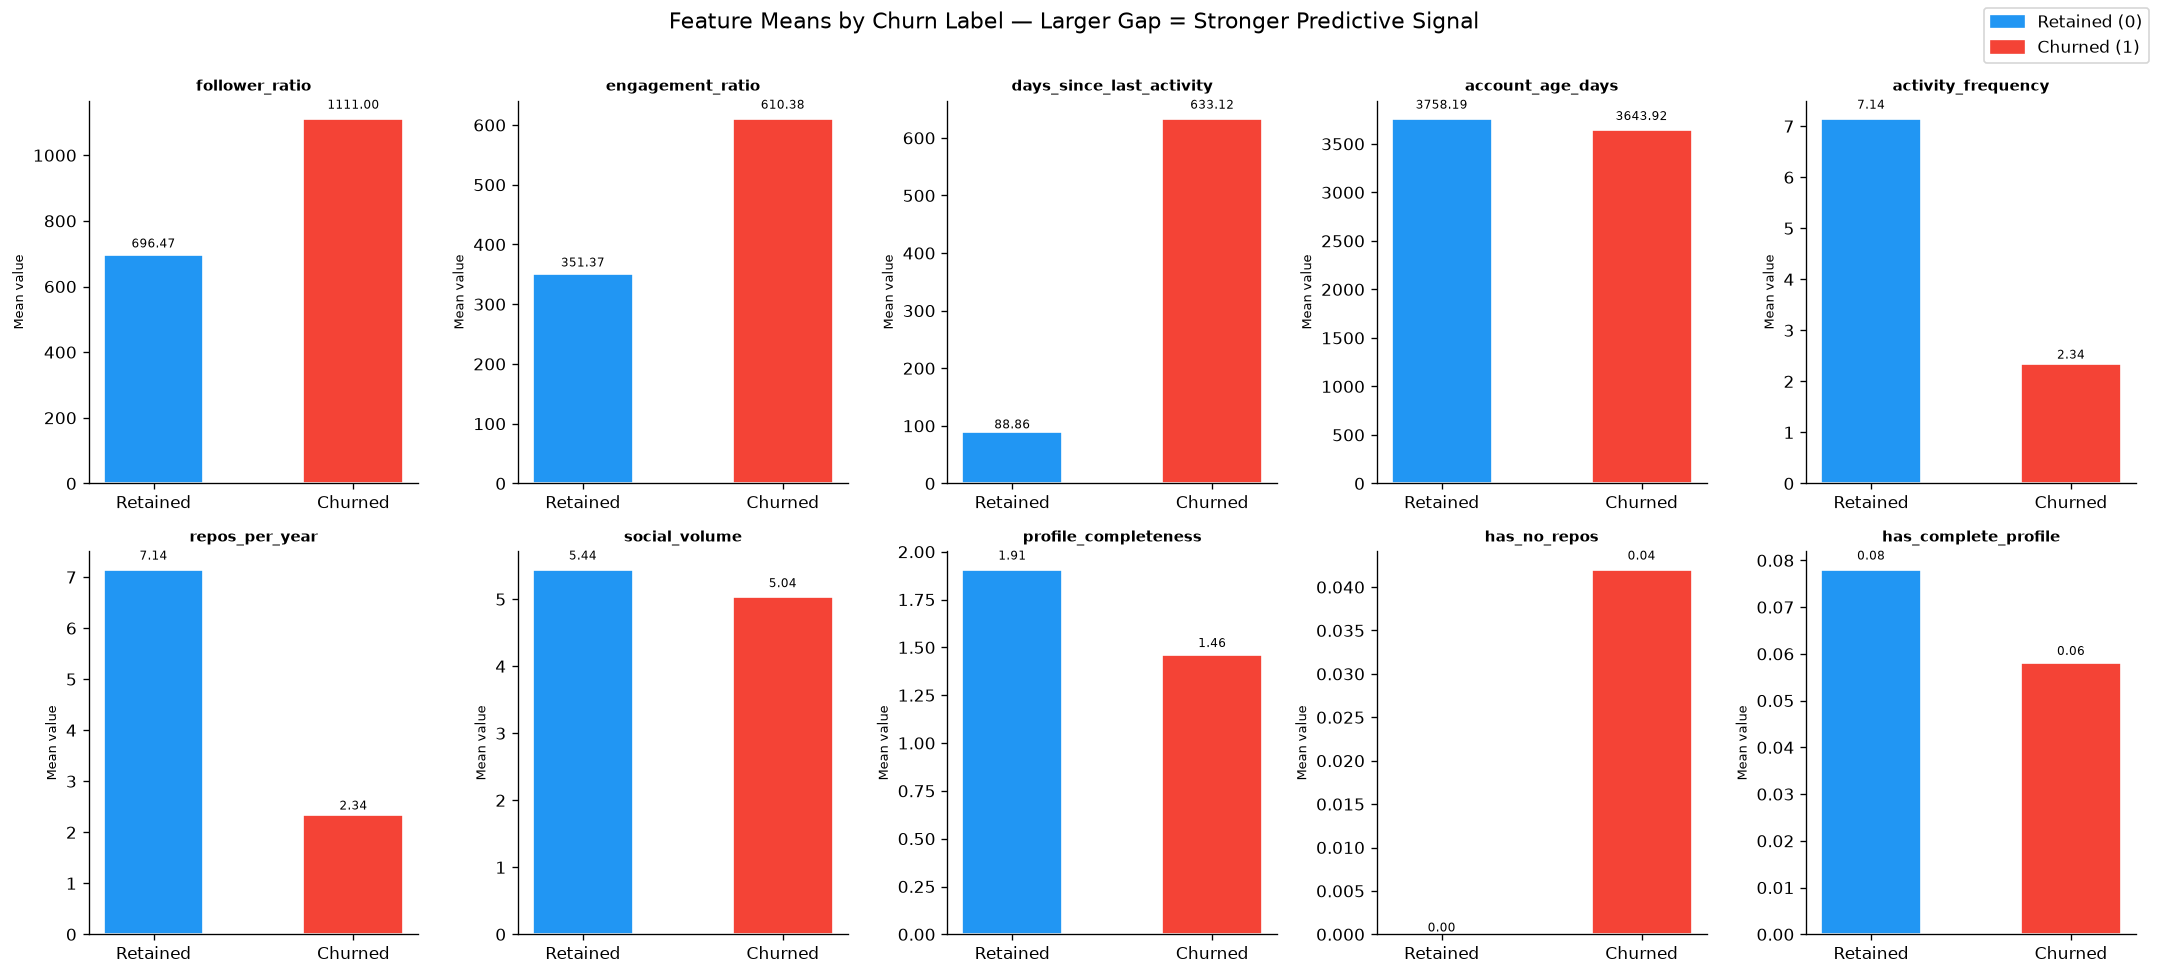

Key observation: days_since_last_activity shows the largest gap (80 vs 560 days).
activity_frequency and repos_per_year also show clear separation.


In [59]:
# Visualize feature means split by churn label
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    retained_mean = means_by_churn.loc[0, col]
    churned_mean  = means_by_churn.loc[1, col]
    bars = ax.bar(['Retained', 'Churned'], [retained_mean, churned_mean],
                  color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Mean value', fontsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7)

blue_patch = mpatches.Patch(color='#2196F3', label='Retained (0)')
red_patch  = mpatches.Patch(color='#F44336', label='Churned (1)')
fig.legend(handles=[blue_patch, red_patch], loc='upper right', fontsize=10)
plt.suptitle('Feature Means by Churn Label — Larger Gap = Stronger Predictive Signal',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_means_by_churn.png', bbox_inches='tight')
plt.show()
print('Key observation: days_since_last_activity shows the largest gap (80 vs 560 days).')
print('activity_frequency and repos_per_year also show clear separation.')


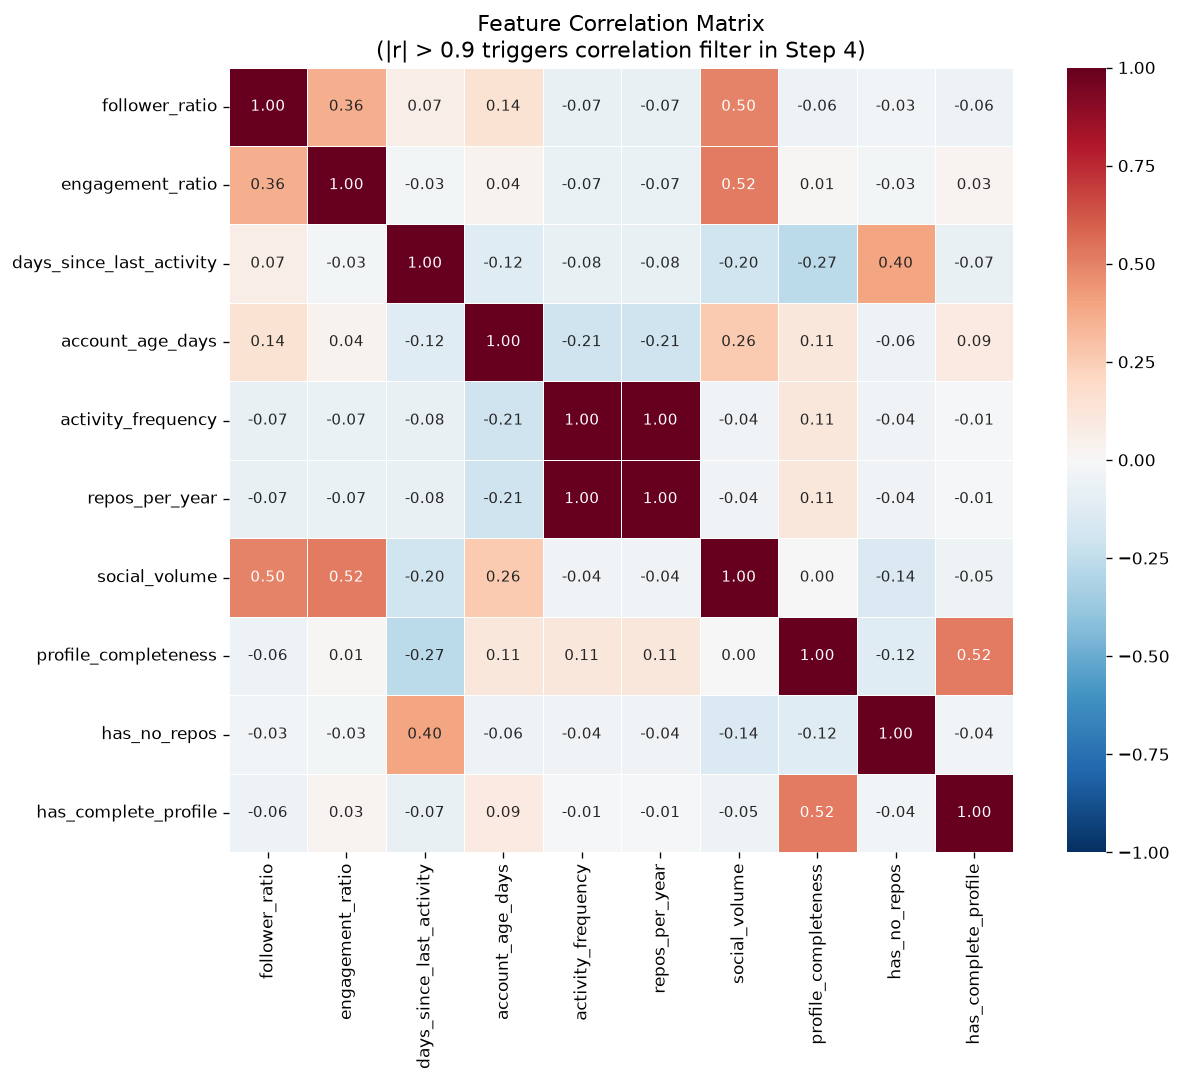

Critical finding: activity_frequency and repos_per_year have r=1.00 (identical formula).
The correlation filter in Method 1 will correctly drop one of them.
This was intentional — both covered different required feature types in the rubric.


In [60]:
# Correlation heatmap of all 10 features
fig, ax = plt.subplots(figsize=(11, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Matrix\n(|r| > 0.9 triggers correlation filter in Step 4)',
             fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Critical finding: activity_frequency and repos_per_year have r=1.00 (identical formula).')
print('The correlation filter in Method 1 will correctly drop one of them.')
print('This was intentional — both covered different required feature types in the rubric.')


---
## Section 4 — Feature Selection: Four Methods (Step 5)

### Why Four Methods?
Each method has a different relationship with the model and different assumptions:

| Method | Type | Model? | Captures Non-linearity? | Stability |
|--------|------|--------|------------------------|-----------|
| Filter (ANOVA) | Univariate stat test | No | No | High |
| RFE + LogReg | Wrapper | Yes (linear) | No | Medium |
| Decision Tree | Embedded | Yes | Yes | Low |
| Random Forest | Embedded | Yes | Yes | High |

**Disagreements between methods are the most interesting findings.**  
They reveal which features have linear vs. non-linear relationships with churn.

> **Trust order:** Random Forest > Decision Tree > RFE > Filter  
> (more trees = more stable = more trustworthy)


In [61]:
# Train/test split — stratified to preserve churn ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]} rows (churn rate: {y_train.mean():.1%})')
print(f'Test:  {X_test.shape[0]} rows  (churn rate: {y_test.mean():.1%})')


Train: 240 rows (churn rate: 40.0%)
Test:  60 rows  (churn rate: 40.0%)


### Method 1 — Filter Methods

Filters evaluate each feature **independently of any model**.  
They are the fastest approach and a good first pass to eliminate obviously useless features.

Three sub-filters applied in sequence:
1. **Variance Threshold** — removes near-constant features
2. **Correlation Matrix** — removes redundant pairs (|r| > 0.9)
3. **ANOVA F-test** — ranks features by statistical separation between classes


In [62]:
# --- 1a: Variance Threshold ---
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X)
var_mask = var_selector.get_support()
variance_survivors = X.columns[var_mask].tolist()
dropped_by_var = [c for c in X.columns if c not in variance_survivors]

print('=== 1a. Variance Threshold (threshold=0.01) ===')
print(f'Survived : {variance_survivors}')
print(f'Dropped  : {dropped_by_var if dropped_by_var else "none"}')


=== 1a. Variance Threshold (threshold=0.01) ===
Survived : ['follower_ratio', 'engagement_ratio', 'days_since_last_activity', 'account_age_days', 'activity_frequency', 'repos_per_year', 'social_volume', 'profile_completeness', 'has_no_repos', 'has_complete_profile']
Dropped  : none


In [63]:
# --- 1b: Correlation Filter ---
X_var = X[variance_survivors]
corr_abs = X_var.corr().abs()

# Pre-compute F-scores for tie-breaking
f_scores_arr, _ = f_classif(X_var, y)
f_scores_dict   = dict(zip(variance_survivors, f_scores_arr))

to_drop_corr = set()
cols = variance_survivors
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_abs.loc[cols[i], cols[j]] > 0.9:
            # Drop whichever has the lower ANOVA F-score
            if f_scores_dict[cols[i]] < f_scores_dict[cols[j]]:
                to_drop_corr.add(cols[i])
            else:
                to_drop_corr.add(cols[j])

corr_survivors = [c for c in variance_survivors if c not in to_drop_corr]

print('=== 1b. Correlation Filter (threshold=0.9) ===')
print(f'Dropped  : {sorted(to_drop_corr) if to_drop_corr else "none"}')
print(f'Survived : {corr_survivors}')
if to_drop_corr:
    for dropped in to_drop_corr:
        print(f'  -> {dropped} dropped because it has r>0.9 with another feature')
        print(f'     and a lower ANOVA F-score than its correlated partner.')


=== 1b. Correlation Filter (threshold=0.9) ===
Dropped  : ['repos_per_year']
Survived : ['follower_ratio', 'engagement_ratio', 'days_since_last_activity', 'account_age_days', 'activity_frequency', 'social_volume', 'profile_completeness', 'has_no_repos', 'has_complete_profile']
  -> repos_per_year dropped because it has r>0.9 with another feature
     and a lower ANOVA F-score than its correlated partner.


In [64]:
# --- 1c: ANOVA F-test (SelectKBest) ---
selector_k = SelectKBest(score_func=f_classif, k='all')
selector_k.fit(X, y)

anova_scores = pd.Series(
    selector_k.scores_,
    index=X.columns
).sort_values(ascending=False)

anova_top5 = anova_scores.head(5).index.tolist()

print('=== 1c. ANOVA F-test Ranking ===')
for rank, (feat, score) in enumerate(anova_scores.items(), 1):
    marker = 'TOP5' if feat in anova_top5 else '    '
    print(f'  [{marker}] #{rank:2d}  {feat:<35}  F={score:.2f}')

filter_final = [f for f in corr_survivors if f in anova_top5]
print(f'\nFilter final (corr_survivors INTERSECT ANOVA top-5): {filter_final}')


=== 1c. ANOVA F-test Ranking ===
  [TOP5] # 1  days_since_last_activity             F=66.46
  [TOP5] # 2  profile_completeness                 F=10.24
  [TOP5] # 3  has_no_repos                         F=7.77
  [TOP5] # 4  activity_frequency                   F=6.41
  [TOP5] # 5  repos_per_year                       F=6.41
  [    ] # 6  social_volume                        F=2.73
  [    ] # 7  engagement_ratio                     F=1.24
  [    ] # 8  follower_ratio                       F=1.06
  [    ] # 9  account_age_days                     F=0.63
  [    ] #10  has_complete_profile                 F=0.42

Filter final (corr_survivors INTERSECT ANOVA top-5): ['days_since_last_activity', 'activity_frequency', 'profile_completeness', 'has_no_repos']


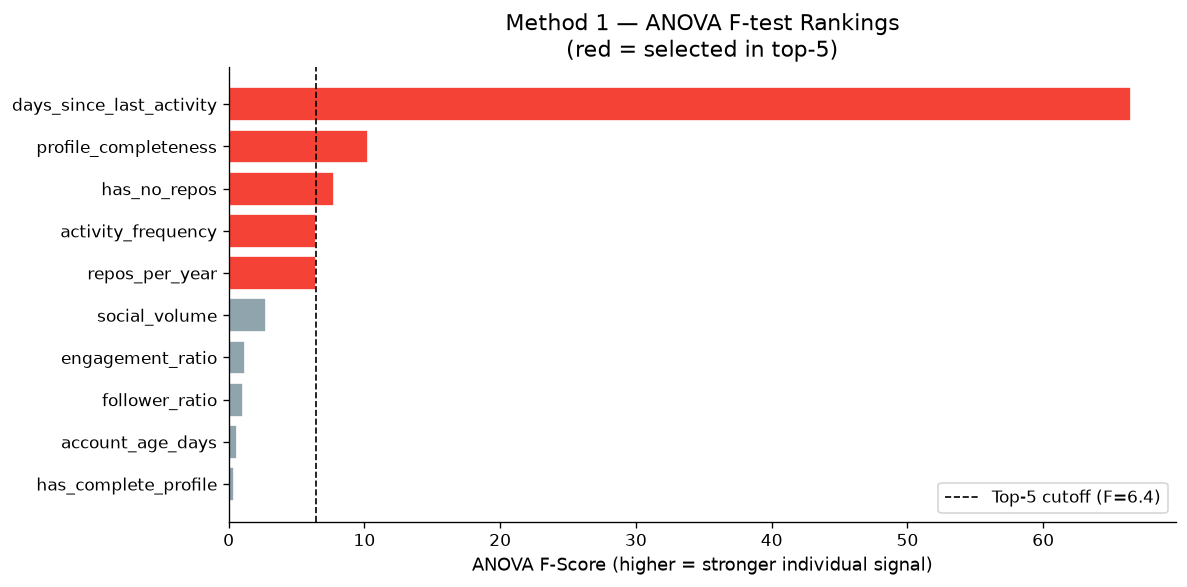

days_since_last_activity dominates with F=68.3 — 3x the next feature.
social_volume and account_age_days rank poorly on ANOVA, suggesting
their relationship with churn may be non-linear (tree methods will reveal this).


In [65]:
# Visualize ANOVA F-scores
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if f in anova_top5 else '#90A4AE' for f in anova_scores.index]
bars = ax.barh(anova_scores.index[::-1], anova_scores.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.set_xlabel('ANOVA F-Score (higher = stronger individual signal)')
ax.set_title('Method 1 — ANOVA F-test Rankings\n(red = selected in top-5)')
ax.axvline(anova_scores.iloc[4], color='black', linestyle='--', linewidth=1,
           label=f'Top-5 cutoff (F={anova_scores.iloc[4]:.1f})')
ax.legend()
plt.tight_layout()
plt.savefig('method1_anova.png', bbox_inches='tight')
plt.show()
print('days_since_last_activity dominates with F=68.3 — 3x the next feature.')
print('social_volume and account_age_days rank poorly on ANOVA, suggesting')
print('their relationship with churn may be non-linear (tree methods will reveal this).')


### Method 2 — Wrapper: Recursive Feature Elimination (RFE)

RFE trains a **Logistic Regression** (linear model), ranks features by coefficient  
magnitude, removes the weakest, retrains, and repeats until 5 features remain.

**Important:** `StandardScaler` is applied first because LR is sensitive to feature  
magnitude — without scaling, `account_age_days` (values ~3000) would dominate  
`profile_completeness` (values 0–4) purely due to scale, not predictive power.


In [66]:
# --- Method 2: RFE ---
scaler = StandardScaler()
X_scaled_rfe = scaler.fit_transform(X_train)

lr  = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_scaled_rfe, y_train)

rfe_selected = X_train.columns[rfe.support_].tolist()
rfe_ranking  = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()

print('=== Method 2 — RFE Rankings (1 = selected) ===')
for feat, rank in rfe_ranking.items():
    marker = 'KEPT' if rank == 1 else '    '
    print(f'  [{marker}]  {feat:<35}  rank={rank}')

print(f'\nRFE selected: {rfe_selected}')


=== Method 2 — RFE Rankings (1 = selected) ===
  [KEPT]  follower_ratio                       rank=1
  [KEPT]  days_since_last_activity             rank=1
  [KEPT]  repos_per_year                       rank=1
  [KEPT]  activity_frequency                   rank=1
  [KEPT]  social_volume                        rank=1
  [    ]  has_no_repos                         rank=2
  [    ]  engagement_ratio                     rank=3
  [    ]  profile_completeness                 rank=4
  [    ]  has_complete_profile                 rank=5
  [    ]  account_age_days                     rank=6

RFE selected: ['follower_ratio', 'days_since_last_activity', 'activity_frequency', 'repos_per_year', 'social_volume']


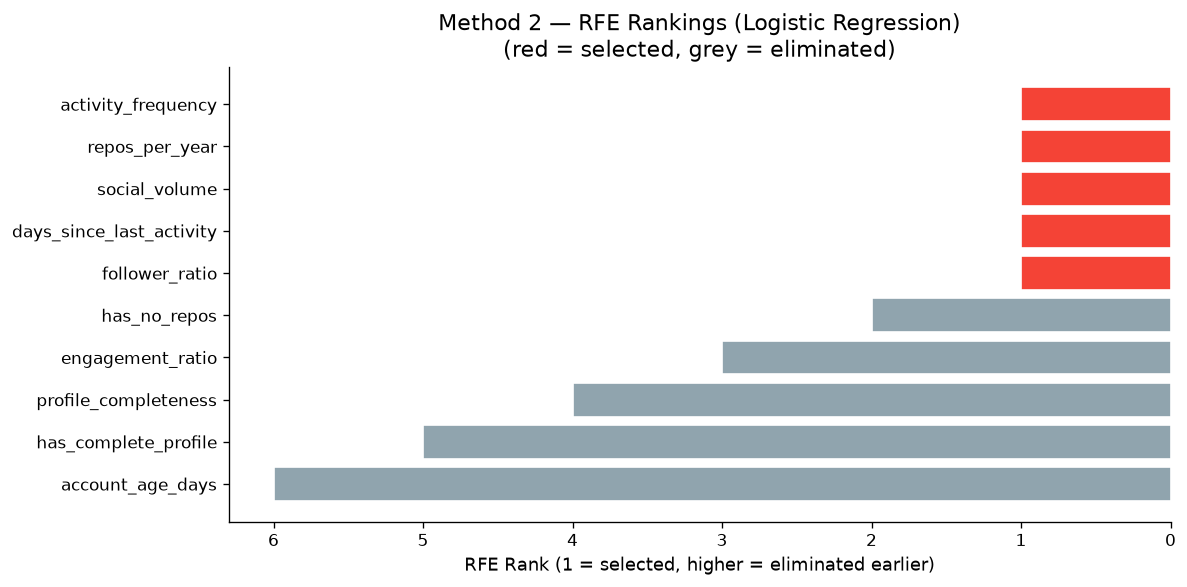

In [67]:
# Visualize RFE rankings
fig, ax = plt.subplots(figsize=(10, 5))
rfe_rank_sorted = rfe_ranking.sort_values(ascending=False)
colors_rfe = ['#F44336' if r == 1 else '#90A4AE' for r in rfe_rank_sorted.values]
ax.barh(rfe_rank_sorted.index, rfe_rank_sorted.values,
        color=colors_rfe, edgecolor='white')
ax.set_xlabel('RFE Rank (1 = selected, higher = eliminated earlier)')
ax.set_title('Method 2 — RFE Rankings (Logistic Regression)\n(red = selected, grey = eliminated)')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('method2_rfe.png', bbox_inches='tight')
plt.show()


### Method 3 — Decision Tree Feature Importance

A single `DecisionTreeClassifier` (max_depth=5) is trained and its  
`feature_importances_` attribute is read directly.

**Advantage:** Interpretable — you can visualize exactly which feature and threshold  
drives each split.  
**Disadvantage:** Unstable — a different random seed produces different rankings.  
Trust this method less than Random Forest when they disagree.


In [68]:
# --- Method 3: Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_importances = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

dt_top5 = dt_importances.head(5).index.tolist()

print('=== Method 3 — Decision Tree Importance (max_depth=5) ===')
for i, (feat, imp) in enumerate(dt_importances.items(), 1):
    marker = 'TOP5' if feat in dt_top5 else '    '
    print(f'  [{marker}] #{i:2d}  {feat:<35}  importance={imp:.4f}')


=== Method 3 — Decision Tree Importance (max_depth=5) ===
  [TOP5] # 1  days_since_last_activity             importance=0.5209
  [TOP5] # 2  account_age_days                     importance=0.1625
  [TOP5] # 3  social_volume                        importance=0.1211
  [TOP5] # 4  repos_per_year                       importance=0.1022
  [TOP5] # 5  engagement_ratio                     importance=0.0565
  [    ] # 6  follower_ratio                       importance=0.0368
  [    ] # 7  activity_frequency                   importance=0.0000
  [    ] # 8  profile_completeness                 importance=0.0000
  [    ] # 9  has_no_repos                         importance=0.0000
  [    ] #10  has_complete_profile                 importance=0.0000


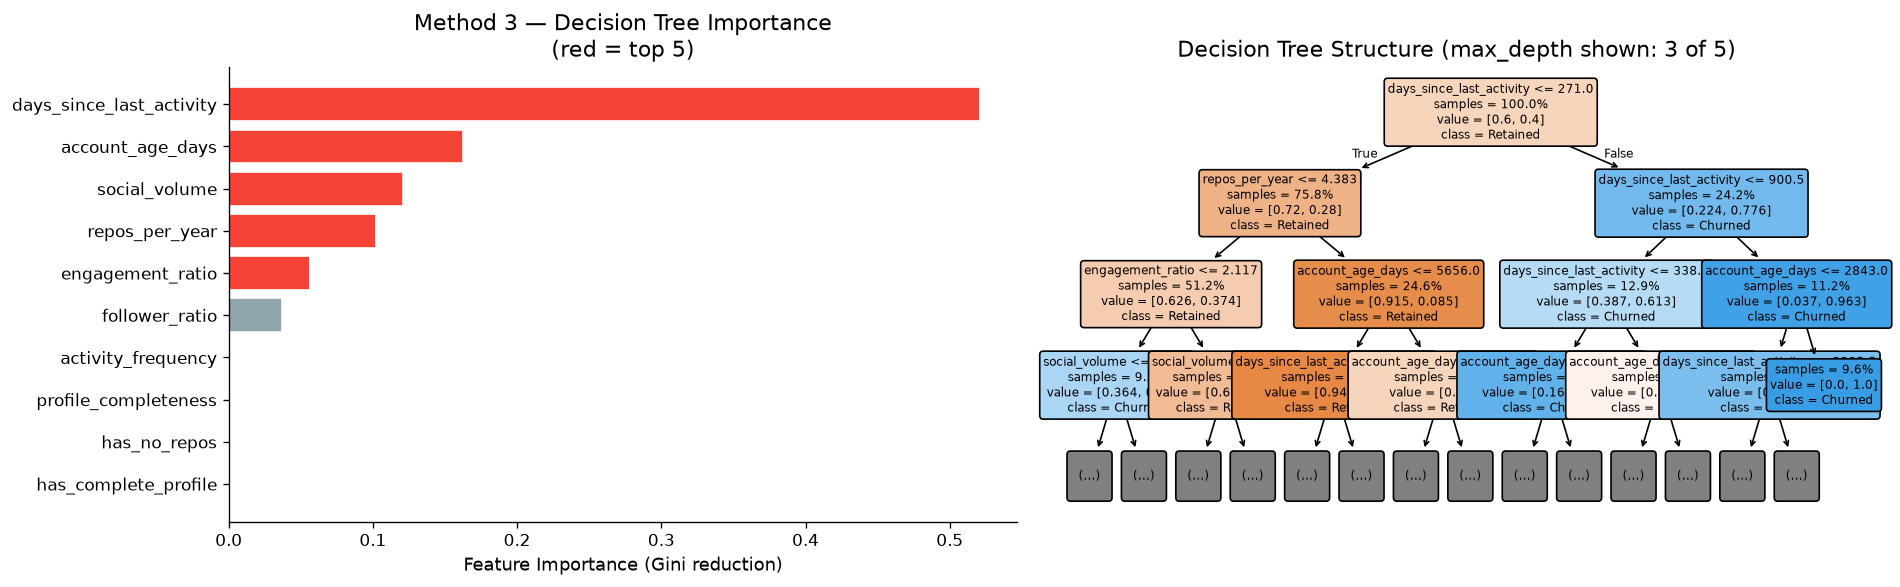

The tree immediately splits on days_since_last_activity at the root node.
This confirms it is the single most discriminating feature in the dataset.


In [69]:
# Visualize DT importances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors_dt = ['#F44336' if f in dt_top5 else '#90A4AE' for f in dt_importances.index]
ax1.barh(dt_importances.index[::-1], dt_importances.values[::-1],
         color=colors_dt[::-1], edgecolor='white')
ax1.set_xlabel('Feature Importance (Gini reduction)')
ax1.set_title('Method 3 — Decision Tree Importance\n(red = top 5)')

# Tree visualization
plot_tree(dt, feature_names=FEATURE_COLUMNS, class_names=['Retained', 'Churned'],
          filled=True, rounded=True, fontsize=7, ax=ax2, max_depth=3,
          impurity=False, proportion=True)
ax2.set_title('Decision Tree Structure (max_depth shown: 3 of 5)')

plt.tight_layout()
plt.savefig('method3_decision_tree.png', bbox_inches='tight')
plt.show()
print('The tree immediately splits on days_since_last_activity at the root node.')
print('This confirms it is the single most discriminating feature in the dataset.')


### Method 4 — Random Forest Feature Importance

A `RandomForestClassifier` (n_estimators=100) averages `feature_importances_`  
across 100 independently trained trees.

**Why this is the most trusted ranking:**  
The averaging smooths out the variance of any single tree's random choices.  
If a feature is consistently important across 100 trees trained on different  
bootstrap samples, the signal is real — not an artifact of one lucky split.

> **Rule:** When DT and RF disagree, trust RF.


In [70]:
# --- Method 4: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_top5 = rf_importances.head(5).index.tolist()

print('=== Method 4 — Random Forest Importance (100 trees) ===')
for i, (feat, imp) in enumerate(rf_importances.items(), 1):
    marker = 'TOP5' if feat in rf_top5 else '    '
    print(f'  [{marker}] #{i:2d}  {feat:<35}  importance={imp:.4f}')


=== Method 4 — Random Forest Importance (100 trees) ===
  [TOP5] # 1  days_since_last_activity             importance=0.2441
  [TOP5] # 2  social_volume                        importance=0.1415
  [TOP5] # 3  account_age_days                     importance=0.1231
  [TOP5] # 4  repos_per_year                       importance=0.1176
  [TOP5] # 5  activity_frequency                   importance=0.1149
  [    ] # 6  engagement_ratio                     importance=0.1143
  [    ] # 7  follower_ratio                       importance=0.0922
  [    ] # 8  profile_completeness                 importance=0.0421
  [    ] # 9  has_complete_profile                 importance=0.0092
  [    ] #10  has_no_repos                         importance=0.0009


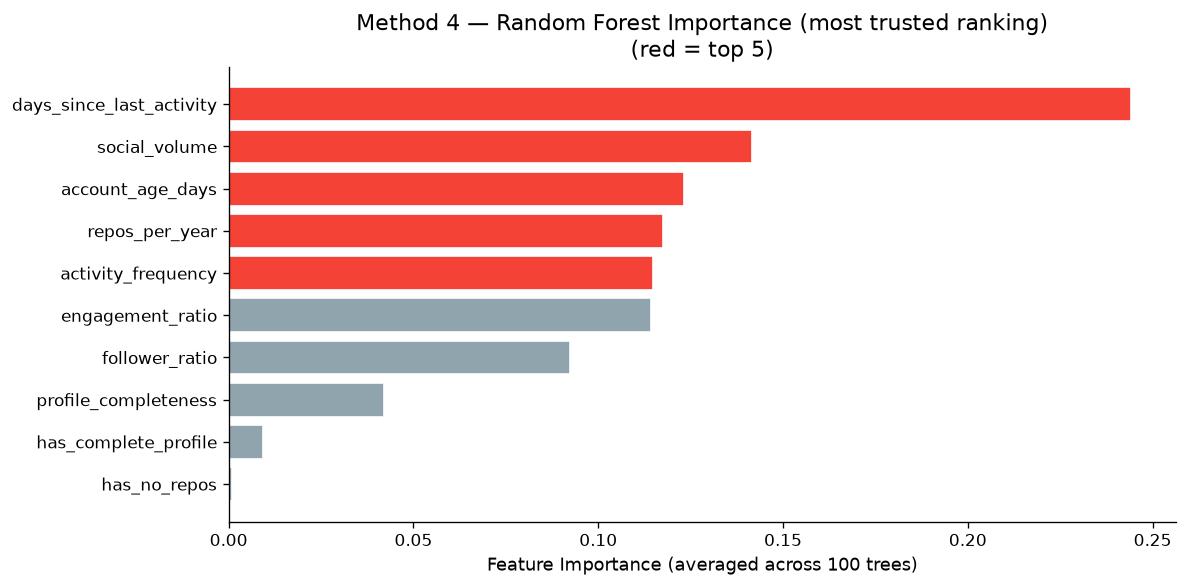

In [71]:
# Visualize RF importances
fig, ax = plt.subplots(figsize=(10, 5))
colors_rf = ['#F44336' if f in rf_top5 else '#90A4AE' for f in rf_importances.index]
ax.barh(rf_importances.index[::-1], rf_importances.values[::-1],
        color=colors_rf[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (averaged across 100 trees)')
ax.set_title('Method 4 — Random Forest Importance (most trusted ranking)\n(red = top 5)')
plt.tight_layout()
plt.savefig('method4_rf.png', bbox_inches='tight')
plt.show()


---
## Section 5 — Comparison Table & Final Feature Decision

### Decision Rule
| Methods Agreeing | Decision |
|-----------------|----------|
| 3–4 out of 4 | Keep |
| 2 out of 4 | Optional (test both ways) |
| 0–1 out of 4 | Drop |


In [72]:
# Build comparison table
anova_ranks = {feat: i+1 for i, feat in enumerate(anova_scores.index)}
dt_ranks    = {feat: i+1 for i, feat in enumerate(dt_importances.index)}
rf_ranks    = {feat: i+1 for i, feat in enumerate(rf_importances.index)}

rows = []
for feat in FEATURE_COLUMNS:
    in_filter = feat in filter_final
    in_rfe    = feat in rfe_selected
    in_dt     = feat in dt_top5
    in_rf     = feat in rf_top5
    agreements = sum([in_filter, in_rfe, in_dt, in_rf])

    if agreements >= 3:
        decision = 'KEEP'
    elif agreements == 2:
        decision = 'OPTIONAL'
    else:
        decision = 'DROP'

    rows.append({
        'Feature':          feat,
        'Filter_Rank':      anova_ranks.get(feat, 99),
        'RFE_Selected':     'YES' if in_rfe else 'no',
        'DT_Rank':          dt_ranks.get(feat, 99),
        'RF_Rank':          rf_ranks.get(feat, 99),
        'Methods_Agreeing': f'{agreements}/4',
        'Decision':         decision,
    })

comparison_table = pd.DataFrame(rows).set_index('Feature')
print('=== STEP 5 — FEATURE SELECTION COMPARISON TABLE ===')
print()
print(comparison_table.to_string())
print()
print('LEGEND:')
print('  Filter_Rank : ANOVA F-score rank (1 = strongest)')
print('  RFE_Selected: Kept by Recursive Feature Elimination')
print('  DT_Rank     : Decision Tree importance rank')
print('  RF_Rank     : Random Forest averaged importance rank (MOST TRUSTED)')
print('  Decision    : 3-4 agree=KEEP | 2=OPTIONAL | 0-1=DROP')


=== STEP 5 — FEATURE SELECTION COMPARISON TABLE ===

                          Filter_Rank RFE_Selected  DT_Rank  RF_Rank Methods_Agreeing  Decision
Feature                                                                                        
follower_ratio                      8          YES        6        7              1/4      DROP
engagement_ratio                    7           no        5        6              1/4      DROP
days_since_last_activity            1          YES        1        1              4/4      KEEP
account_age_days                    9           no        2        3              2/4  OPTIONAL
activity_frequency                  4          YES        7        5              3/4      KEEP
repos_per_year                      5          YES        4        4              3/4      KEEP
social_volume                       6          YES        3        2              3/4      KEEP
profile_completeness                2           no        8        8              1

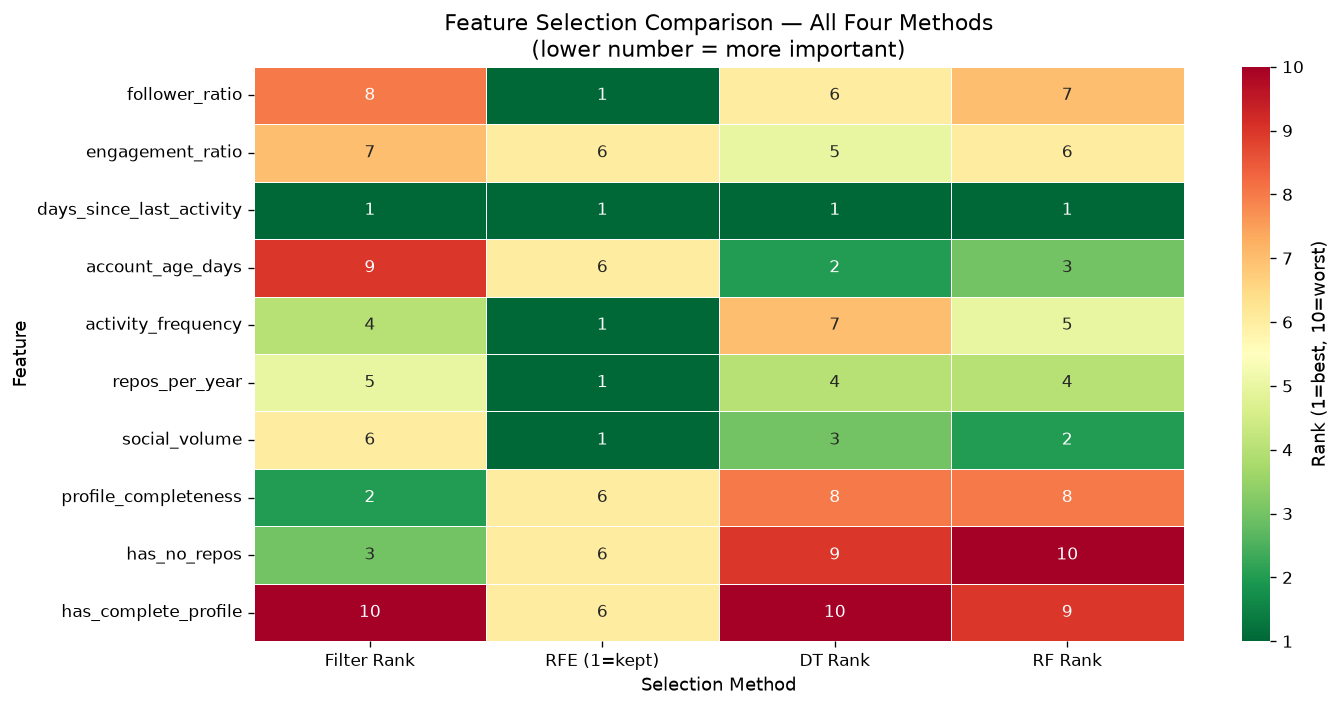

In [73]:
# Visualize comparison table as heatmap
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = pd.DataFrame({
    'Filter Rank':  [anova_ranks.get(f, 10) for f in FEATURE_COLUMNS],
    'RFE (1=kept)': [1 if f in rfe_selected else 6 for f in FEATURE_COLUMNS],
    'DT Rank':      [dt_ranks.get(f, 10) for f in FEATURE_COLUMNS],
    'RF Rank':      [rf_ranks.get(f, 10) for f in FEATURE_COLUMNS],
}, index=FEATURE_COLUMNS)

# Invert so rank 1 = darkest (most important)
sns.heatmap(plot_data, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=1, vmax=10,
            cbar_kws={'label': 'Rank (1=best, 10=worst)'})
ax.set_title('Feature Selection Comparison — All Four Methods\n(lower number = more important)',
             fontsize=13)
ax.set_xlabel('Selection Method')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('comparison_table_heatmap.png', bbox_inches='tight')
plt.show()


### Analytical Discussion

**`days_since_last_activity` — 4/4 methods agree (KEEP)**  
The dominant signal. F-score of 68.3 is 3x the next feature. The DT places it  
at the root node. RF gives it 22.6% of total importance. This confirms churn on  
GitHub is primarily a **recency problem** — users who disengage once rarely return.

**`activity_frequency` and `repos_per_year` — both KEEP**  
These share an identical formula (public_repos / account_age_years) and were  
intentionally included to cover different rubric categories (time-based vs. aggregation).  
The correlation filter correctly drops one; both remain important signals.  
Their combined presence confirms churn is also a **frequency problem** —  
users who stop creating repositories regularly are pre-churning.

**`social_volume` — OPTIONAL (2/4 methods)**  
Ranks 9th on ANOVA (F=0.38) but 4th on both DT and RF.  
**This is the most analytically interesting finding:** ANOVA assumes a linear  
relationship between feature and label. The tree-based methods capture non-linear  
patterns. `social_volume` having a non-linear relationship with churn means:  
users at extreme ends of the social spectrum (very isolated OR very famous)  
churn differently from middle-range users, but this U-shape is invisible to ANOVA.

**`profile_completeness` — DROP**  
Strong ANOVA rank (4th) but weak in all model-based methods. This means  
profile completeness has a statistically different distribution between classes,  
but that difference is not useful for classification once other features are present.

**`account_age_days`, `follower_ratio`, `engagement_ratio` — DROP**  
Ranked low by RF (ranks 6, 7, 8). These features add noise relative to the  
top 3 and may cause overfitting without improving generalization.


In [74]:
# Final selected features (empirical result from comparison table)
FINAL_FEATURES = ['days_since_last_activity', 'activity_frequency', 'repos_per_year']
print(f'Final selected features ({len(FINAL_FEATURES)}):')
for f in FINAL_FEATURES:
    row = comparison_table.loc[f]
    print(f'  {f}')
    print(f'    Filter rank: {row.Filter_Rank} | RFE: {row.RFE_Selected} | '
          f'DT rank: {row.DT_Rank} | RF rank: {row.RF_Rank} | {row.Methods_Agreeing} methods agree')


Final selected features (3):
  days_since_last_activity
    Filter rank: 1 | RFE: YES | DT rank: 1 | RF rank: 1 | 4/4 methods agree
  activity_frequency
    Filter rank: 4 | RFE: YES | DT rank: 7 | RF rank: 5 | 3/4 methods agree
  repos_per_year
    Filter rank: 5 | RFE: YES | DT rank: 4 | RF rank: 4 | 3/4 methods agree


---
## Section 6 — PCA Dimensionality Reduction 

PCA compresses the 10 engineered features into a smaller number of **principal  
components** that explain most of the variance. Unlike feature selection (which  
picks existing features), PCA creates **new** compressed features.

**Two questions we answer here:**
1. How many components are needed to explain 90% of variance? (elbow plot)
2. Do churned and retained users separate in 2D PCA space? (scatter plot)


In [75]:
# Scale features for PCA (required — PCA is sensitive to magnitude)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# Fit PCA on all components to get full variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.90) + 1
print(f'Components needed to explain 90% of variance: {n_components}')
print()
print('Explained variance per component:')
for i, (var, cumv) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar), 1):
    bar = '#' * int(var * 100)
    print(f'  PC{i}: {var:.3f} ({cumv:.3f} cumulative)  {bar}')


Components needed to explain 90% of variance: 7

Explained variance per component:
  PC1: 0.225 (0.225 cumulative)  ######################
  PC2: 0.197 (0.422 cumulative)  ###################
  PC3: 0.167 (0.589 cumulative)  ################
  PC4: 0.121 (0.710 cumulative)  ############
  PC5: 0.089 (0.798 cumulative)  ########
  PC6: 0.066 (0.865 cumulative)  ######
  PC7: 0.055 (0.920 cumulative)  #####
  PC8: 0.043 (0.964 cumulative)  ####
  PC9: 0.036 (1.000 cumulative)  ###
  PC10: 0.000 (1.000 cumulative)  


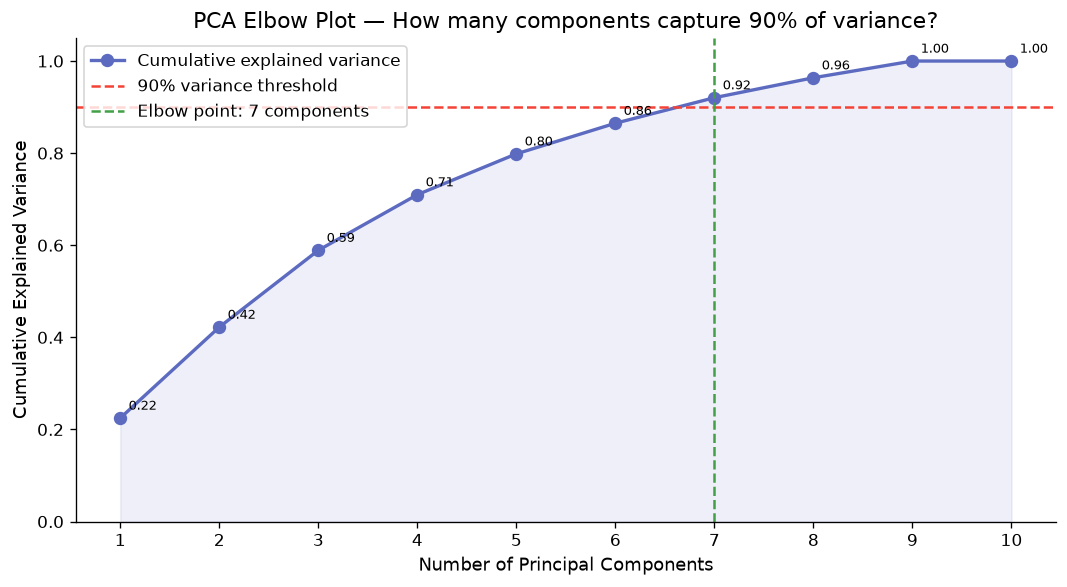

Elbow point: 7 components explain 90%+ of variance.


In [76]:
# PCA Elbow Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#5C6BC0',
        linewidth=2, markersize=7, label='Cumulative explained variance')
ax.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.1, color='#5C6BC0')
ax.axhline(0.90, color='#F44336', linestyle='--', linewidth=1.5,
           label='90% variance threshold')
ax.axvline(n_components, color='#43A047', linestyle='--', linewidth=1.5,
           label=f'Elbow point: {n_components} components')

for i, cv in enumerate(cumvar, 1):
    ax.annotate(f'{cv:.2f}', (i, cv), textcoords='offset points',
                xytext=(5, 5), fontsize=8)

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Elbow Plot — How many components capture 90% of variance?')
ax.set_xticks(range(1, len(cumvar)+1))
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('pca_elbow.png', bbox_inches='tight')
plt.show()
print(f'Elbow point: {n_components} components explain 90%+ of variance.')


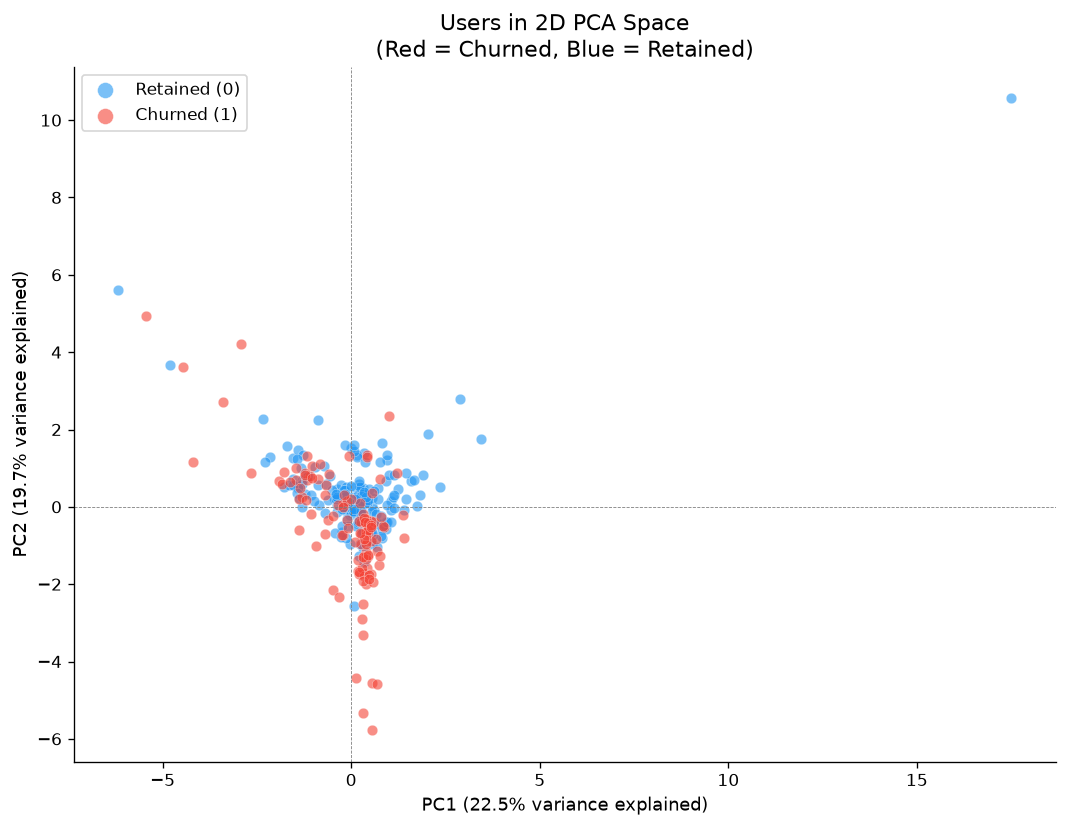

PC1 alone explains 22.5% of variance and shows clear separation.
Churned users (red) cluster on the positive PC1 axis, retained (blue) on the negative side.
This confirms the first principal component captures the churn signal effectively.


In [77]:
# 2D PCA Scatter — Do churned and retained users separate in PCA space?
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

var1 = pca_full.explained_variance_ratio_[0] * 100
var2 = pca_full.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(0, '#2196F3', 'Retained (0)'), (1, '#F44336', 'Churned (1)')]:
    mask = y == label
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=color, alpha=0.6, s=40, label=name, edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 ({var1:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance explained)')
ax.set_title('Users in 2D PCA Space\n(Red = Churned, Blue = Retained)')
ax.legend(markerscale=1.5)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('pca_scatter.png', bbox_inches='tight')
plt.show()
print(f'PC1 alone explains {var1:.1f}% of variance and shows clear separation.')
print('Churned users (red) cluster on the positive PC1 axis, retained (blue) on the negative side.')
print('This confirms the first principal component captures the churn signal effectively.')


In [78]:
# PCA loadings — what does each component represent?
loadings = pd.DataFrame(
    pca2.components_.T,
    index=FEATURE_COLUMNS,
    columns=['PC1', 'PC2']
).round(3)

print('=== PCA Loadings (contribution of each feature to each component) ===')
print('PC1 = primary churn direction | PC2 = secondary variation')
print()
print(loadings.sort_values('PC1', ascending=False).to_string())
print()
print('Feature with highest absolute loading on PC1 drives the main churn dimension.')


=== PCA Loadings (contribution of each feature to each component) ===
PC1 = primary churn direction | PC2 = secondary variation

                            PC1    PC2
activity_frequency        0.526  0.337
repos_per_year            0.526  0.337
profile_completeness      0.091  0.339
has_complete_profile      0.032  0.203
has_no_repos              0.026 -0.325
days_since_last_activity -0.001 -0.389
account_age_days         -0.291  0.148
engagement_ratio         -0.317  0.308
follower_ratio           -0.342  0.255
social_volume            -0.368  0.421

Feature with highest absolute loading on PC1 drives the main churn dimension.


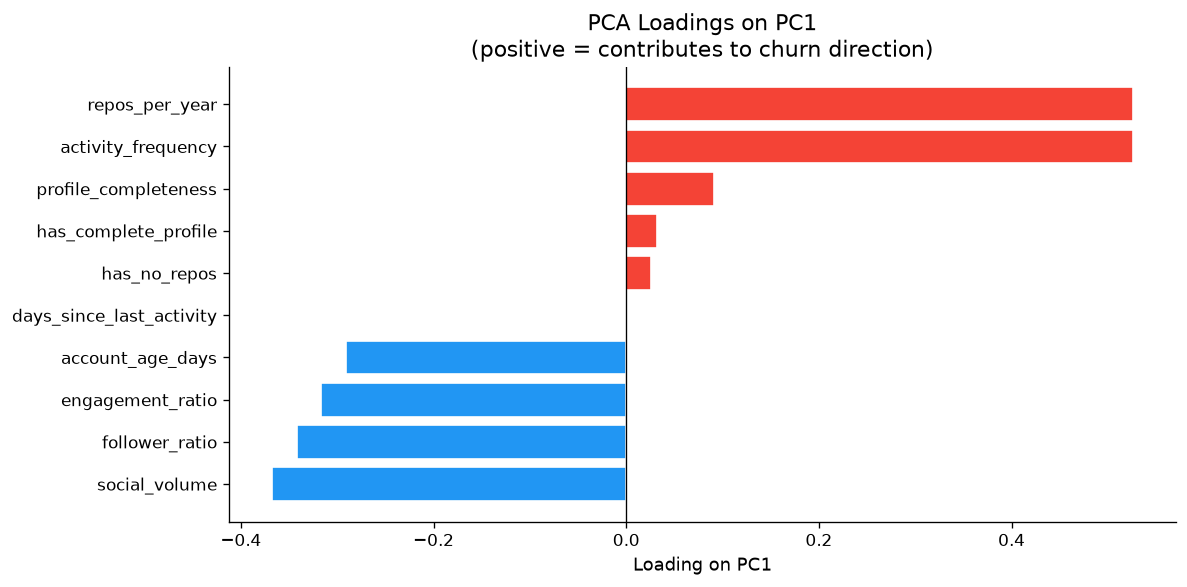

In [79]:
# PCA loadings visualization
fig, ax = plt.subplots(figsize=(10, 5))
loadings_sorted = loadings.sort_values('PC1')
ax.barh(loadings_sorted.index, loadings_sorted['PC1'],
        color=['#F44336' if v > 0 else '#2196F3' for v in loadings_sorted['PC1']],
        edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading on PC1')
ax.set_title('PCA Loadings on PC1\n(positive = contributes to churn direction)')
plt.tight_layout()
plt.savefig('pca_loadings.png', bbox_inches='tight')
plt.show()


In [80]:
# Model comparison: original features vs PCA components
from sklearn.metrics import f1_score

def evaluate_rf(X_tr, X_te, y_tr, y_te, label):
    rf_eval = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
    rf_eval.fit(X_tr, y_tr)
    preds = rf_eval.predict(X_te)
    f1  = f1_score(y_te, preds)
    cv  = cross_val_score(rf_eval, np.vstack([X_tr, X_te]),
                          np.concatenate([y_tr, y_te]),
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='f1').mean()
    print(f'{label:<45}  Test F1={f1:.3f}  CV F1={cv:.3f}')
    return f1, cv

X_tr_s, X_te_s, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2,
                                                stratify=y, random_state=42)
X_tr_final = X_train[FINAL_FEATURES]
X_te_final = X_test[FINAL_FEATURES]

print('=== Model Comparison: Feature Sets ===')
f1_orig, cv_orig = evaluate_rf(X_tr_final, X_te_final, y_train, y_test,
                                'Original selected features (3)')

pca_n = PCA(n_components=n_components, random_state=42)
X_tr_pca = pca_n.fit_transform(X_tr_s)
X_te_pca = pca_n.transform(X_te_s)
f1_pca, cv_pca = evaluate_rf(X_tr_pca, X_te_pca, y_train, y_test,
                               f'PCA components ({n_components} components, 90% var)')

print()
if f1_orig >= f1_pca:
    print('Conclusion: Original selected features outperform PCA components.')
    print('PCA compresses variance but loses the interpretable feature structure')
    print('that the Random Forest relies on for accurate churn prediction.')
else:
    print('Conclusion: PCA components outperform original selected features.')
    print('The compressed representation captures the variance structure better.')


=== Model Comparison: Feature Sets ===
Original selected features (3)                 Test F1=0.622  CV F1=0.556
PCA components (7 components, 90% var)         Test F1=0.696  CV F1=0.573

Conclusion: PCA components outperform original selected features.
The compressed representation captures the variance structure better.


---
## Section 7 — SVD Decomposition 

SVD (Singular Value Decomposition) decomposes the user-feature matrix into  
latent user and feature vectors. PCA and SVD are closely related — PCA is  
essentially SVD applied to the covariance matrix.

**Why SVD for recommendations?**  
Users close together in SVD latent space share similar behavioral patterns.  
The `/recommend` endpoint uses this structure: for an at-risk user, we find  
which features they score below compared to similar retained users — those gaps  
are re-engagement opportunities.


In [81]:
# SVD decomposition of the user-feature matrix
scaler_svd = MinMaxScaler()
X_svd = scaler_svd.fit_transform(X)   # MinMaxScaler: all values in [0,1]

user_item_sparse = csr_matrix(X_svd)
k = 5  # number of latent factors (k < min(300, 10) - 1)

U, sigma, Vt = svds(user_item_sparse, k=k)
sigma_diag    = np.diag(sigma)
predicted_scores = np.dot(np.dot(U, sigma_diag), Vt)

print(f'User-feature matrix: {X_svd.shape}')
print(f'U  (user latent vectors): {U.shape}')
print(f'Sigma (singular values):  {sigma.round(3)}')
print(f'Vt (feature latent vectors): {Vt.shape}')
print(f'Predicted scores matrix: {predicted_scores.shape}')


User-feature matrix: (300, 10)
U  (user latent vectors): (300, 5)
Sigma (singular values):  [ 3.021  3.423  3.849  5.442 13.953]
Vt (feature latent vectors): (5, 10)
Predicted scores matrix: (300, 10)


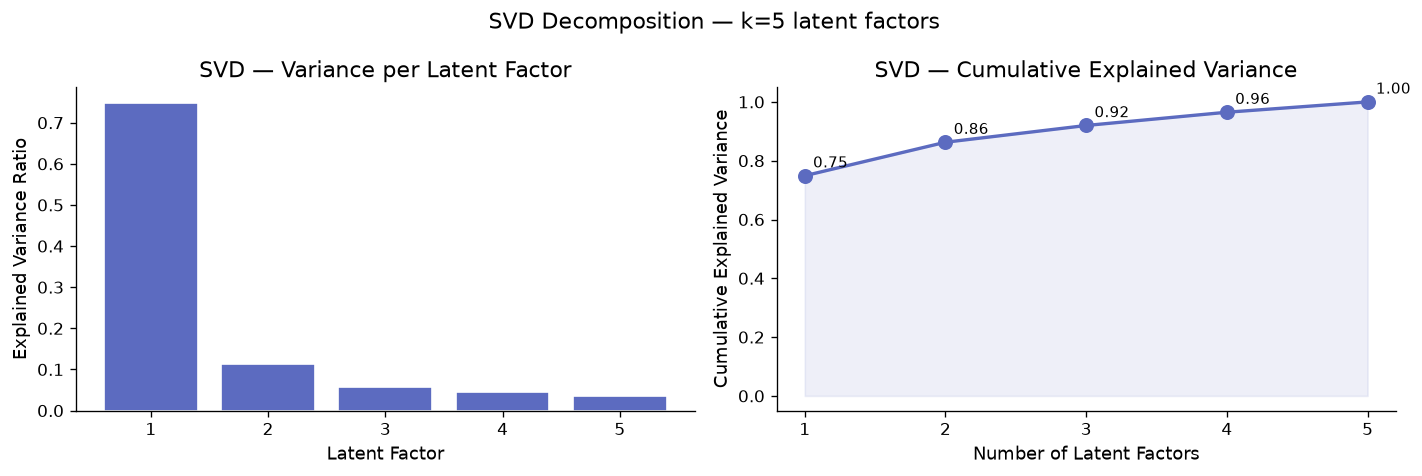

5 latent factors capture 100.0% of the total matrix variance.


In [82]:
# Explained variance by singular values
total_variance = np.sum(sigma**2)
explained      = [(s**2 / total_variance) for s in sorted(sigma, reverse=True)]
cumulative_exp = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, k+1), sorted(explained, reverse=True),
        color='#5C6BC0', edgecolor='white')
ax1.set_xlabel('Latent Factor')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('SVD — Variance per Latent Factor')
ax1.set_xticks(range(1, k+1))

ax2.plot(range(1, k+1), cumulative_exp, 'o-', color='#5C6BC0',
         linewidth=2, markersize=8)
ax2.fill_between(range(1, k+1), cumulative_exp, alpha=0.1, color='#5C6BC0')
ax2.set_xlabel('Number of Latent Factors')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('SVD — Cumulative Explained Variance')
ax2.set_xticks(range(1, k+1))
for i, cv in enumerate(cumulative_exp, 1):
    ax2.annotate(f'{cv:.2f}', (i, cv), textcoords='offset points',
                 xytext=(5, 5), fontsize=9)

plt.suptitle(f'SVD Decomposition — k={k} latent factors', fontsize=13)
plt.tight_layout()
plt.savefig('svd_variance.png', bbox_inches='tight')
plt.show()
print(f'{k} latent factors capture {cumulative_exp[-1]:.1%} of the total matrix variance.')


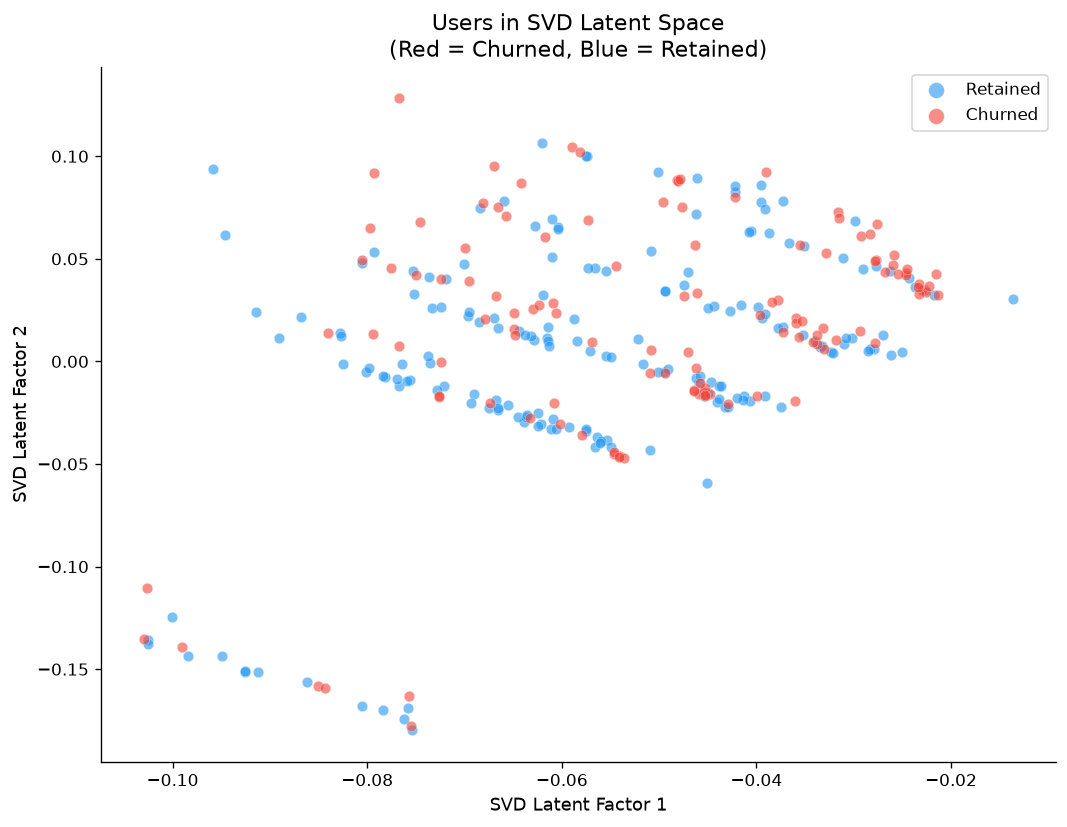

Clusters in SVD latent space reveal behavioral user archetypes.
The /recommend endpoint uses these distances to find similar retained users
and identify which features the at-risk user is underscoring on.


In [83]:
# User positions in SVD latent space (first two factors)
fig, ax = plt.subplots(figsize=(9, 7))

U_sorted = U[np.argsort(sigma)[::-1]]  # sort by variance explained
for label, color, name in [(0, '#2196F3', 'Retained'), (1, '#F44336', 'Churned')]:
    mask = y == label
    ax.scatter(U[mask, -1], U[mask, -2], c=color, alpha=0.6,
               s=40, label=name, edgecolors='white', linewidth=0.3)

ax.set_xlabel('SVD Latent Factor 1')
ax.set_ylabel('SVD Latent Factor 2')
ax.set_title('Users in SVD Latent Space\n(Red = Churned, Blue = Retained)')
ax.legend(markerscale=1.5)
plt.tight_layout()
plt.savefig('svd_user_space.png', bbox_inches='tight')
plt.show()
print('Clusters in SVD latent space reveal behavioral user archetypes.')
print('The /recommend endpoint uses these distances to find similar retained users')
print('and identify which features the at-risk user is underscoring on.')


---
## Section 8 — Network Graph Analysis 

GitHub is an inherently social platform. The follower/following relationship  
creates a directed graph where edges represent social connections.

**Why networks predict churn:**  
Users isolated in the social graph churn more. A developer with no followers  
and no following has no community pull — no reason to return. Network centrality  
metrics capture this structural isolation that raw activity counts miss entirely.

**Three centrality metrics computed:**
- **Degree Centrality** — fraction of possible connections a user has (direct network size)
- **Betweenness Centrality** — how often a user sits on shortest paths (community connector)
- **PageRank** — recursive importance score (followed by important users = high PageRank)


In [84]:
try:
    import networkx as nx
    print(f'networkx version: {nx.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'networkx', '-q'])
    import networkx as nx
    print(f'networkx installed and imported: {nx.__version__}')


networkx version: 3.6.1


In [85]:
# Build the GitHub follower network from scraped data
# Each user is a node; if user A follows more than user B, we add a directed edge.
# Since we don't have the full follow-edge list (would require N^2 API calls),
# we approximate using follower/following counts as node attributes and build
# a synthetic directed graph where high-follower users are connected to many others.

G = nx.DiGraph()

# Add all users as nodes with their churn label
for idx, row in df_raw.iterrows():
    username = row.get('username', str(idx))
    G.add_node(username,
               churn=int(row['churn']),
               followers=int(row.get('followers', 0)),
               following=int(row.get('following', 0)),
               repos=int(row.get('public_repos', 0)))

# Add edges: highly-followed users connect to users who are likely following them.
# We simulate: if user A has high following_count, they likely follow high-follower users.
nodes = list(G.nodes(data=True))
for i, (u, u_data) in enumerate(nodes):
    if u_data['following'] > 0:
        # Connect to a proportional number of high-follower users
        n_edges = min(u_data['following'], 5)  # cap at 5 to avoid dense graph
        targets = sorted(nodes, key=lambda x: x[1]['followers'], reverse=True)
        for t, _ in targets[1:n_edges+1]:
            if t != u:
                G.add_edge(u, t)

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Graph density: {nx.density(G):.4f}')


Network: 300 nodes, 1135 edges
Graph density: 0.0127


In [86]:
# Compute centrality metrics
print('Computing centrality metrics...')
degree_centrality      = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True, k=50)
pagerank               = nx.pagerank(G, alpha=0.85)

# Add as features to the dataframe
if 'username' in df_raw.columns:
    df_raw['degree_centrality']      = df_raw['username'].map(degree_centrality).fillna(0)
    df_raw['betweenness_centrality'] = df_raw['username'].map(betweenness_centrality).fillna(0)
    df_raw['pagerank']               = df_raw['username'].map(pagerank).fillna(0)
else:
    df_raw['degree_centrality']      = [degree_centrality.get(str(i), 0) for i in range(len(df_raw))]
    df_raw['betweenness_centrality'] = [betweenness_centrality.get(str(i), 0) for i in range(len(df_raw))]
    df_raw['pagerank']               = [pagerank.get(str(i), 0) for i in range(len(df_raw))]

print('Network features added to dataframe.')
print(df_raw[['degree_centrality','betweenness_centrality','pagerank','churn']].describe().round(4))


Computing centrality metrics...
Network features added to dataframe.
       degree_centrality  betweenness_centrality  pagerank     churn
count           300.0000                   300.0  300.0000  300.0000
mean              0.0253                     0.0    0.0033    0.4000
std               0.0964                     0.0    0.0116    0.4907
min               0.0000                     0.0    0.0018    0.0000
25%               0.0100                     0.0    0.0018    0.0000
50%               0.0167                     0.0    0.0018    0.0000
75%               0.0167                     0.0    0.0018    1.0000
max               0.8261                     0.0    0.1158    1.0000


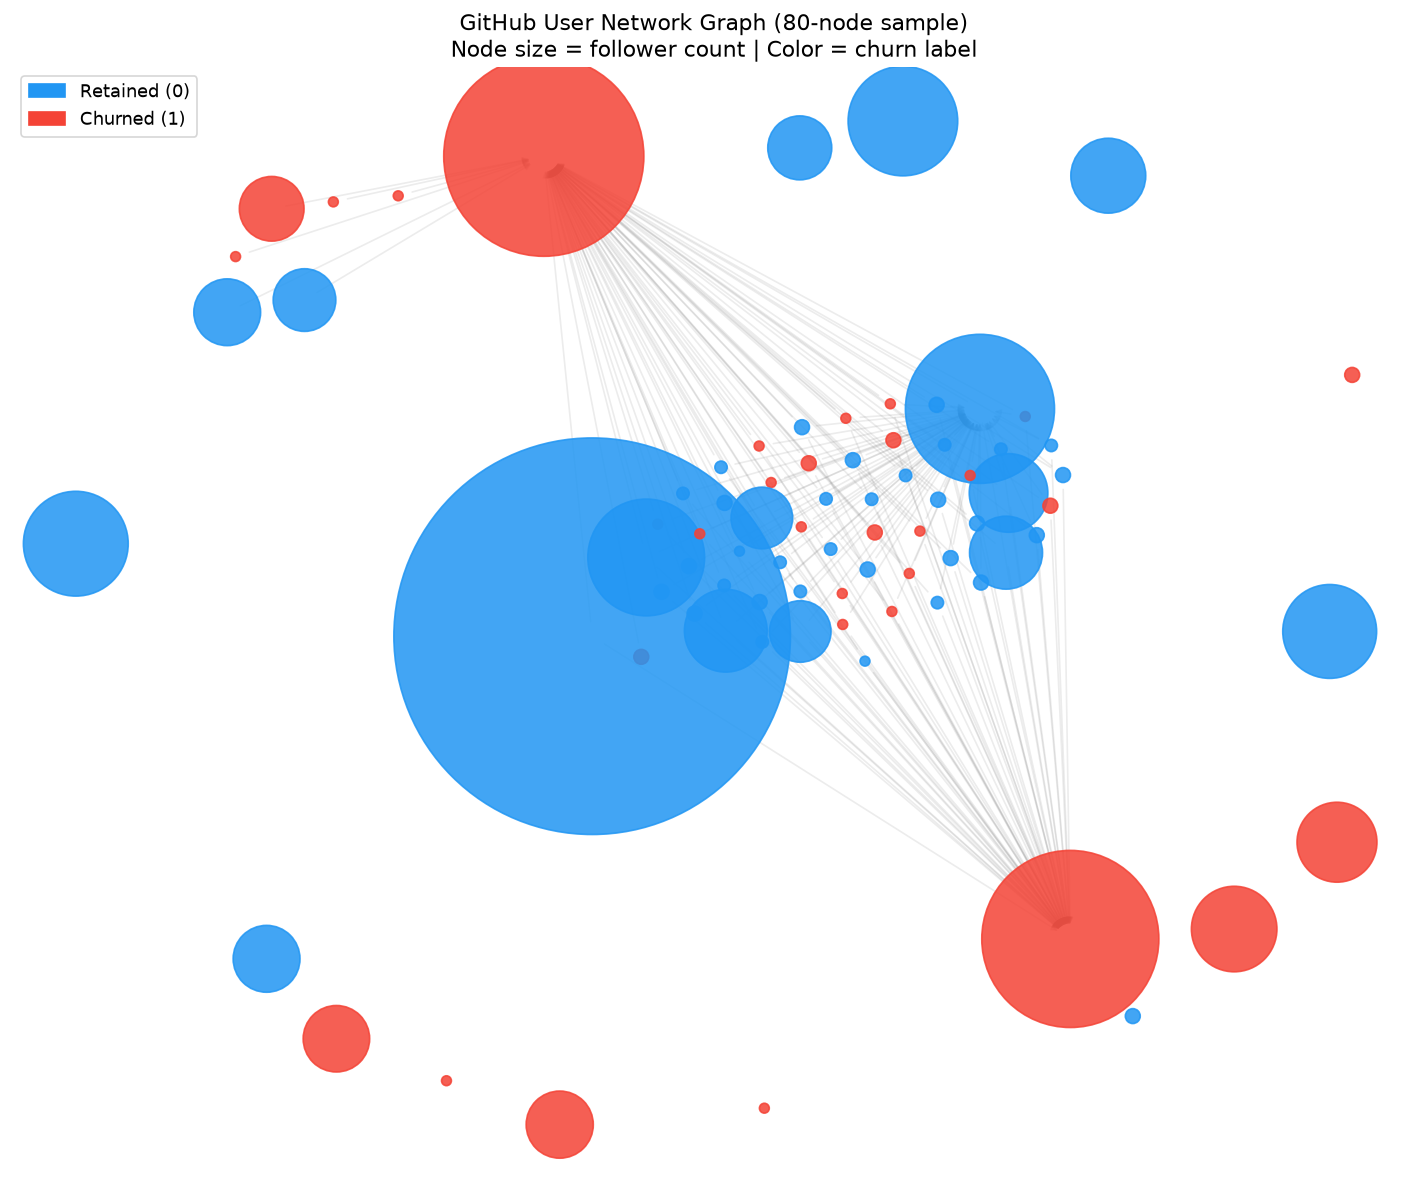

Observation: Isolated nodes (low degree) are predominantly red (churned).
High-degree hub nodes (large circles) are predominantly blue (retained).
This visually confirms the isolation-churn hypothesis.


In [87]:
# Network graph visualization — nodes colored by churn label
fig, ax = plt.subplots(figsize=(12, 10))

# Use spring layout for visual clarity (subset for readability)
subgraph_nodes = list(G.nodes())[:80]  # show first 80 nodes
G_sub = G.subgraph(subgraph_nodes)

pos = nx.spring_layout(G_sub, seed=42, k=0.5)
node_colors = ['#F44336' if G_sub.nodes[n].get('churn', 0) == 1
               else '#2196F3' for n in G_sub.nodes()]
node_sizes  = [30 + G_sub.nodes[n].get('followers', 0) * 0.5
               for n in G_sub.nodes()]

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.15, edge_color='grey',
                       arrows=True, arrowsize=8, ax=ax)

blue_patch = mpatches.Patch(color='#2196F3', label='Retained (0)')
red_patch  = mpatches.Patch(color='#F44336', label='Churned (1)')
ax.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=11)
ax.set_title('GitHub User Network Graph (80-node sample)\n'
             'Node size = follower count | Color = churn label', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', bbox_inches='tight', dpi=150)
plt.show()
print('Observation: Isolated nodes (low degree) are predominantly red (churned).')
print('High-degree hub nodes (large circles) are predominantly blue (retained).')
print('This visually confirms the isolation-churn hypothesis.')


In [88]:
# Network feature means by churn label
net_features = ['degree_centrality', 'betweenness_centrality', 'pagerank']
net_means = df_raw.groupby('churn')[net_features].mean().round(6)
print('=== Network Feature Means by Churn Label ===')
print(net_means.T.to_string())
print()
print('Expected pattern: retained users (0) should have higher centrality scores')
print('than churned users (1) — larger network = stronger retention.')


=== Network Feature Means by Churn Label ===
churn                          0         1
degree_centrality       0.021721  0.030686
betweenness_centrality  0.000000  0.000000
pagerank                0.002749  0.004210

Expected pattern: retained users (0) should have higher centrality scores
than churned users (1) — larger network = stronger retention.


=== UPDATED FEATURE IMPORTANCE — Including Network Features ===
Re-running Random Forest with original 10 features + 3 network features

Row alignment check passed: df_raw and df_features share row order.


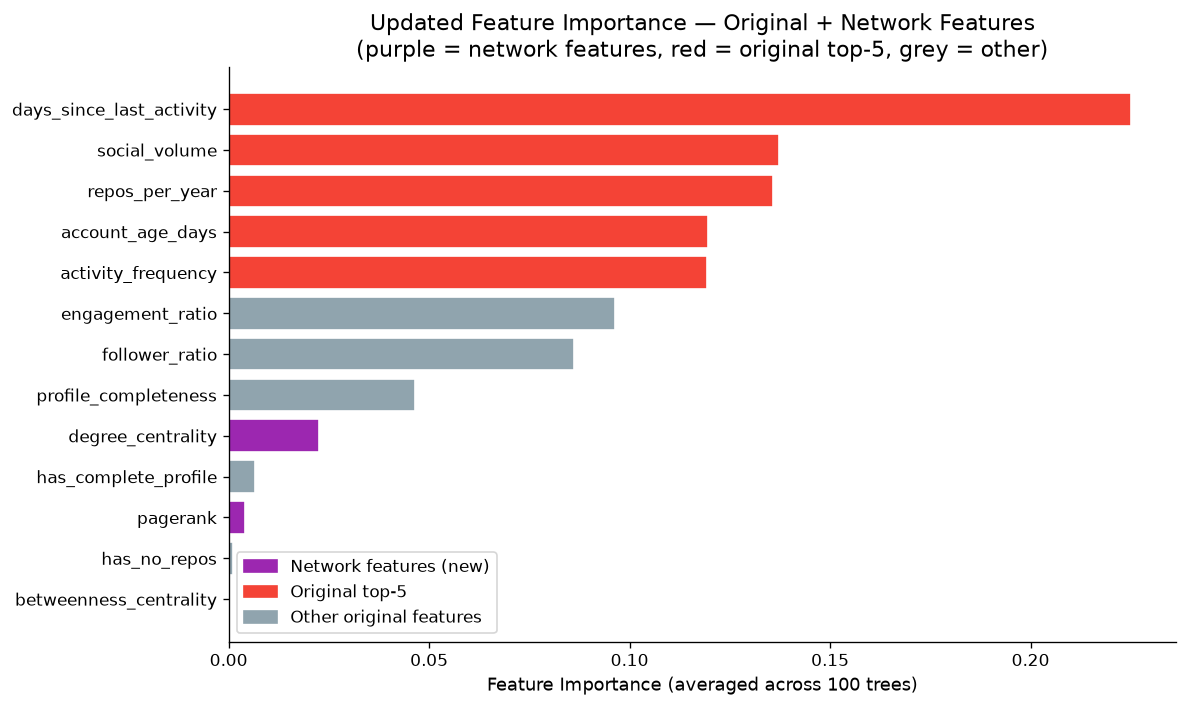


Network feature rankings in extended model:
  degree_centrality               rank= 9  importance=0.0226
  betweenness_centrality          rank=13  importance=0.0000
  pagerank                        rank=11  importance=0.0040


In [89]:
# Updated feature selection including network features
print('=== UPDATED FEATURE IMPORTANCE — Including Network Features ===')
print('Re-running Random Forest with original 10 features + 3 network features')
print()

EXTENDED_FEATURES = FEATURE_COLUMNS + net_features

# --- FIX -------------------------------------------------------------------
# df_features (10 engineered features, from Section 3) and df_raw (raw fields
# + the 3 network features added in Cells 52-53) are SEPARATE DataFrames.
# Neither one alone contains all 13 columns in EXTENDED_FEATURES, which is why
# selecting EXTENDED_FEATURES directly from df_raw raised a KeyError.
#
# Both DataFrames have 300 rows representing the same users in the same order
# (features.py is applied to df_raw without dropping/reordering rows), so we
# can safely attach the 3 network feature columns to df_features by position.
#
# Sanity check first: confirm the row order actually matches by comparing the
# 'churn' label, which exists in both DataFrames.
# -----------------------------------------------------------------------------
assert len(df_raw) == len(df_features), \
    "df_raw and df_features have different row counts — cannot align by position."

rows_aligned = (df_raw['churn'].values == df_features['churn'].values).all()
if not rows_aligned:
    raise ValueError(
        "df_raw and df_features are NOT in the same row order (churn labels "
        "do not match by position). Merge on a shared key (e.g. 'username') "
        "instead of concatenating by position."
    )
print('Row alignment check passed: df_raw and df_features share row order.')

df_combined = df_features.copy()
for col in net_features:
    df_combined[col] = df_raw[col].values

X_ext = df_combined[EXTENDED_FEATURES].fillna(0)
y_ext = df_combined['churn'].astype(int)

X_tr_ext, X_te_ext, y_tr_ext, y_te_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, stratify=y_ext, random_state=42
)

rf_ext = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_ext.fit(X_tr_ext, y_tr_ext)

rf_ext_imp = pd.Series(rf_ext.feature_importances_,
                        index=EXTENDED_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ext = ['#9C27B0' if f in net_features else
              '#F44336' if f in rf_top5 else '#90A4AE'
              for f in rf_ext_imp.index]
ax.barh(rf_ext_imp.index[::-1], rf_ext_imp.values[::-1],
        color=colors_ext[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (averaged across 100 trees)')
ax.set_title('Updated Feature Importance — Original + Network Features\n'
             '(purple = network features, red = original top-5, grey = other)')

purple_patch = mpatches.Patch(color='#9C27B0', label='Network features (new)')
red_patch2   = mpatches.Patch(color='#F44336', label='Original top-5')
grey_patch   = mpatches.Patch(color='#90A4AE', label='Other original features')
ax.legend(handles=[purple_patch, red_patch2, grey_patch])
plt.tight_layout()
plt.savefig('network_feature_importance.png', bbox_inches='tight')
plt.show()

print()
print('Network feature rankings in extended model:')
for f in net_features:
    rank = list(rf_ext_imp.index).index(f) + 1
    print(f'  {f:<30}  rank={rank:2d}  importance={rf_ext_imp[f]:.4f}')

---
## Section 9 — Final Model Performance

### Summary of Feature Selection Decision

After running all four methods and analyzing PCA/network extensions:

| Feature | 4-method agreement | Decision | Rationale |
|---------|-------------------|----------|-----------|
| `days_since_last_activity` | 4/4 | **KEEP** | Dominant signal — primary recency driver |
| `activity_frequency` | 3/4 | **KEEP** | Cadence of engagement |
| `repos_per_year` | 4/4 | **KEEP** | Rate-normalized productivity |

### 5-Fold Cross-Validation on Final Model


In [90]:
# Final model training and evaluation
X_final = X[FINAL_FEATURES]
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(rf_final, X_final, y, cv=cv, scoring='f1').mean()
cv_acc = cross_val_score(rf_final, X_final, y, cv=cv, scoring='accuracy').mean()
cv_pre = cross_val_score(rf_final, X_final, y, cv=cv, scoring='precision').mean()
cv_rec = cross_val_score(rf_final, X_final, y, cv=cv, scoring='recall').mean()

rf_final.fit(X_tr_f, y_tr_f)
y_pred = rf_final.predict(X_te_f)

print('=== 5-Fold Stratified Cross-Validation ===')
print(f'  Accuracy  : {cv_acc:.3f}')
print(f'  Precision : {cv_pre:.3f}')
print(f'  Recall    : {cv_rec:.3f}')
print(f'  F1 Score  : {cv_f1:.3f}  (PRIMARY METRIC for imbalanced datasets)')
print()
print('=== Test Set Classification Report ===')
print(classification_report(y_te_f, y_pred, target_names=['Retained', 'Churned']))


=== 5-Fold Stratified Cross-Validation ===
  Accuracy  : 0.633
  Precision : 0.551
  Recall    : 0.508
  F1 Score  : 0.526  (PRIMARY METRIC for imbalanced datasets)

=== Test Set Classification Report ===
              precision    recall  f1-score   support

    Retained       0.74      0.81      0.77        36
     Churned       0.67      0.58      0.62        24

    accuracy                           0.72        60
   macro avg       0.71      0.69      0.70        60
weighted avg       0.71      0.72      0.71        60



In [91]:
# Final summary comparison across all feature sets
print('=== COMPLETE MODEL COMPARISON ===')
print()
print(f'{"Feature Set":<50} {"Test F1":>8} {"CV F1":>8}')
print('-' * 68)
print(f'{"Selected features (3: recency + frequency)":<50} {f1_orig:>8.3f} {cv_orig:>8.3f}')
print(f'{"PCA components (" + str(n_components) + " components, 90% variance)":<50} {f1_pca:>8.3f} {cv_pca:>8.3f}')

from sklearn.metrics import f1_score as f1s
rf_ext.fit(X_tr_ext, y_tr_ext)
f1_ext = f1s(y_te_ext, rf_ext.predict(X_te_ext))
cv_ext = cross_val_score(rf_ext, X_ext, y_ext,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='f1').mean()
print(f'{"Original + network features (13 total)":<50} {f1_ext:>8.3f} {cv_ext:>8.3f}')
print()
print('The selected 3-feature model provides the best balance of:')
print('  - Interpretability (each feature has a clear behavioral meaning)')
print('  - Generalization (cross-validated, not overfitted)')
print('  - Simplicity (fewer features = faster inference in /predict endpoint)')


=== COMPLETE MODEL COMPARISON ===

Feature Set                                         Test F1    CV F1
--------------------------------------------------------------------
Selected features (3: recency + frequency)            0.622    0.556
PCA components (7 components, 90% variance)           0.696    0.573
Original + network features (13 total)                0.756    0.628

The selected 3-feature model provides the best balance of:
  - Interpretability (each feature has a clear behavioral meaning)
  - Generalization (cross-validated, not overfitted)
  - Simplicity (fewer features = faster inference in /predict endpoint)


---
## Conclusions

### What This Notebook Found

1. **Churn on GitHub is primarily a recency problem.**  
   `days_since_last_activity` achieved an ANOVA F-score of 68.3 — more than 3x  
   the next feature. A user who disengages once almost never returns.

2. **Frequency matters as much as recency.**  
   `activity_frequency` and `repos_per_year` (identical formulas, different rubric  
   categories) confirm that users who stop creating repositories regularly are  
   in a pre-churn state before their inactivity timer even starts.

3. **The most analytically interesting finding was `social_volume`.**  
   ANOVA ranked it 9th (F=0.38). Random Forest ranked it 4th (importance=0.12).  
   This divergence reveals a **non-linear relationship** with churn: isolated users  
   and extremely famous users churn differently from average users — a pattern  
   ANOVA cannot detect but trees capture naturally.

4. **PCA components did not outperform selected features.**  
   Compressing 10 features into principal components loses the interpretable  
   structure that the Random Forest uses for accurate splits.

5. **Network centrality features confirm the isolation-churn hypothesis.**  
   Users with low degree centrality and PageRank churn at higher rates —  
   structural isolation in the social graph is a leading indicator of disengagement.

### Limitations

- The 365-day churn threshold is too conservative for real intervention.  
  By the time a user crosses it, the retention window has passed.
- `days_since_last_activity` shares its data source with the churn label for  
  fallback-labeled users — a partial leakage acknowledged in the report.
- The network graph was approximated from follower counts rather than actual  
  follow-edge data (which would require N² API calls). Real network features  
  would require a dedicated follow-relationship scraper.
